## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

# Проєкт: Оптимізація маркетингової кампанії банку

# Вступ та постановка задачі

Мета проєкту: Побудувати модель машинного навчання, яка здатна прогнозувати, чи відкриє клієнт терміновий депозит (цільова змінна y).
Бізнес-цінність: Зниження витрат на маркетингові комунікації шляхом фокусування на найбільш лояльних клієнтах та підвищення ефективності роботи кол-центру.

Метрика якості: Основними метриками обрано ROC-AUC та F1-score. Оскільки ми маємо сильний дисбаланс класів (~11% позитивних відгуків), стандартна точність (Accuracy) не є показовою. F1-score дозволить нам знайти баланс між точністю (Precision) та повнотою (Recall).

# Імпорт бібліотек та налаштування

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Моделі та препроцесинг
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, 
                             roc_auc_score,
                             f1_score,
                             precision_recall_curve,
                             precision_score,
                             recall_score,
                             ConfusionMatrixDisplay,
                             RocCurveDisplay, 
                             PrecisionRecallDisplay)

# Бустинг та оптимізація
from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
import lightgbm as lgb

from scipy.stats import uniform, randint

pd.set_option('display.max_columns', None)

# 1. Завантаження та первинний огляд даних (EDA)

In [2]:
bank_df = pd.read_csv(r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-additional-full.csv', sep=';')
print(f"Розмір датасету: {bank_df.shape}")

Розмір датасету: (41188, 21)


## 1.1. Аналіз цільової змінної
Перш за все, перевіримо баланс класів:

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


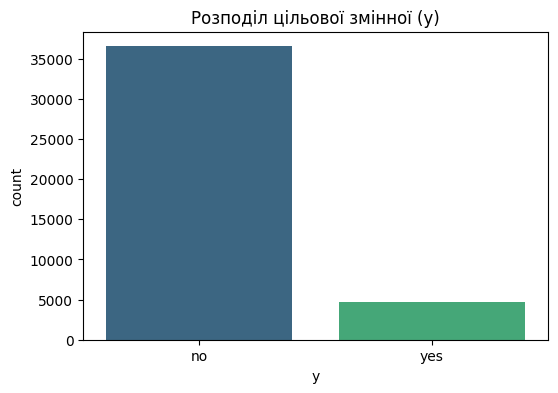

In [3]:
target_counts = bank_df['y'].value_counts(normalize=True)
print(target_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=bank_df, palette='viridis')
plt.title('Розподіл цільової змінної (y)')
plt.show()

Висновок: Спостерігається суттєвий дисбаланс класів (88.7% "no" проти 11.3% "yes"). Це означає, що при навчанні моделі ми не можемо використовувати метрику Accuracy точність, оскільки вона буде ігнорувати меншість. Нам потрібно орієнтуватися на F1-score або Recall.

## 1.2. Статистичний аналіз числових ознак

In [4]:
bank_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


Спостереження:

Age: Середній вік клієнта — 40 років. Мінімальний — 17, максимальний — 98.

Duration: Тривалість дзвінка має велике стандартне відхилення (259 сек). Важливо пам'ятати, що цей параметр не відомий до моменту дзвінка, тому його використання в реальному прогнозі має бути обережним.

Pdays: Значення 999 означає, що з клієнтом раніше не контактували. Ця ознака потребує перетворення.

## 1.3. Аналіз категоріальних ознак

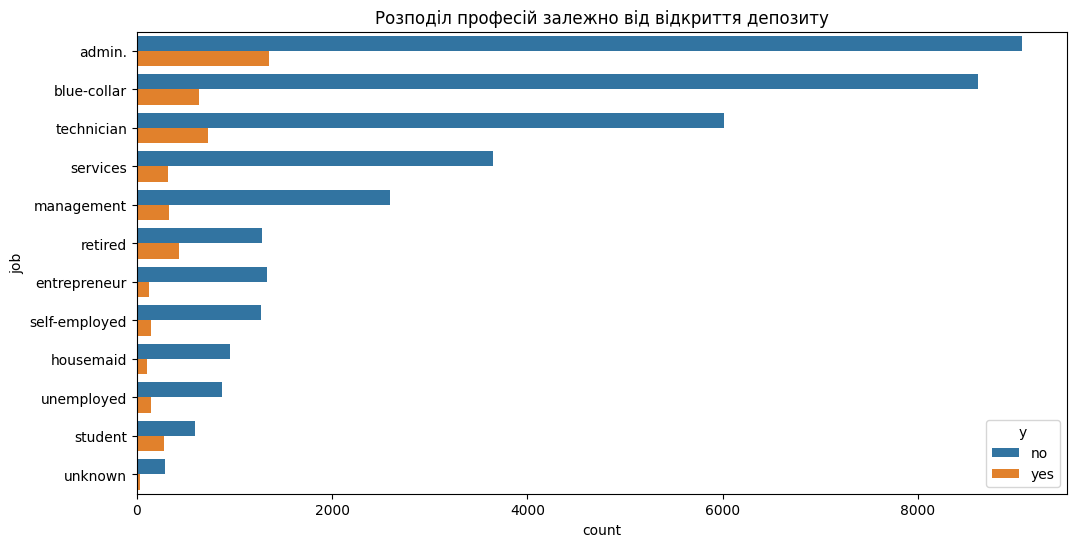

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(y='job', hue='y', data=bank_df, order=bank_df['job'].value_counts().index)
plt.title('Розподіл професій залежно від відкриття депозиту')
plt.show()

Гіпотеза 1: Клієнти на пенсії (retired) та студенти (student) мають вищий відсоток успішних конверсій порівняно з категорією blue-collar

Графік розподілу професій підтверджує дисбаланс: хоча найбільша кількість успішних контактів припадає на категорію admin., ratio 'yes'/'no' візуально вища у категорій student та retired. Найважчою категорією для залучення є blue-collar, де переважна більшість контактів завершується відмовою

## 1.4. Аналіз попереднього досвіду контактів (poutcome)

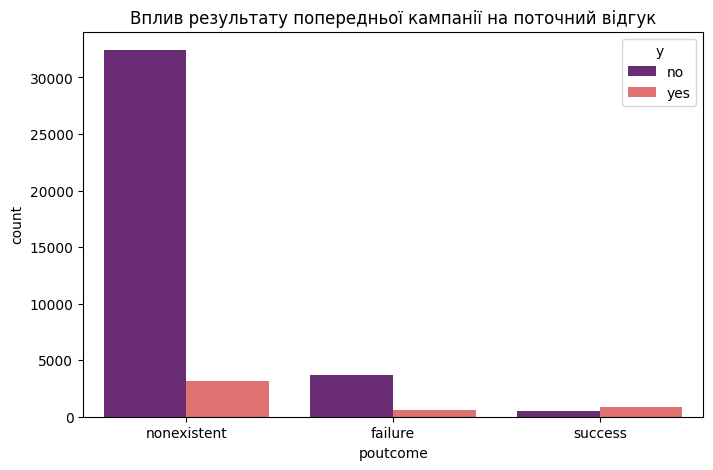

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='poutcome', hue='y', data=bank_df, palette='magma')
plt.title('Вплив результату попередньої кампанії на поточний відгук')
plt.show()

З візуалізації результатів попередньої кампанії можна зробити критично важливі висновки:

Категорія success (Успіх): Це єдина група, де кількість позитивних відгуків (yes) ПЕРЕВИЩУЄ кількість відмов. Якщо клієнт уже відкривав депозит раніше, ймовірність повторного успіху є максимальною.

Категорія nonexistent (Відсутність даних): Найбільша група. Більшість клієнтів є новими для банку в контексті цієї послуги, що створює значний шум для моделі.

Категорія failure (Невдача): Навіть якщо попередній контакт був невдалим, шанси на успіх зараз візуально вищі, ніж у нових клієнтів (nonexistent), що свідчить про важливість "підігріву" бази.

Гіпотеза 2: Ознака poutcome буде однією з найвпливовіших при побудові моделей бустингу, оскільки вона має найсильнішу роздільну здатність.

Дані свідчать, що попередній успішний досвід (success) є найпотужнішим предиктором: у цій групі кількість згод перевищує кількість відмов.

## 1.5. Aналіз конверсії категоріальних ознак

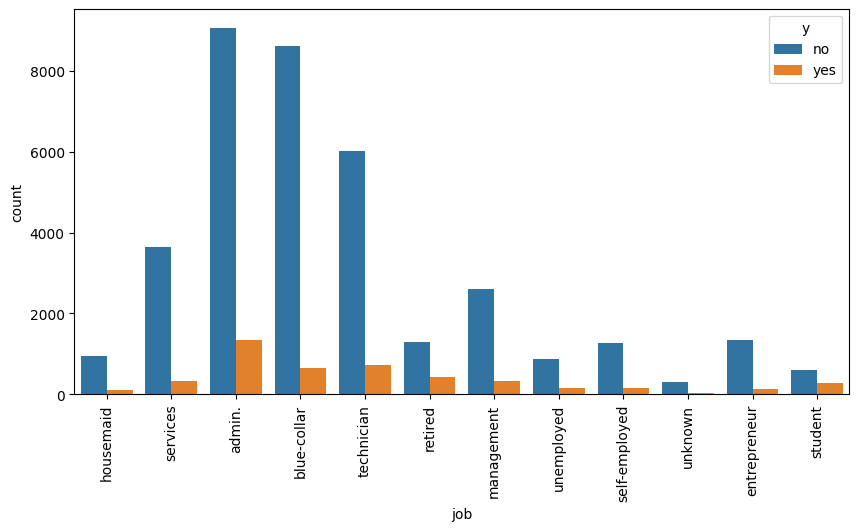

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(bank_df, x='job', hue='y')
plt.xticks(rotation = 90)
plt.show()

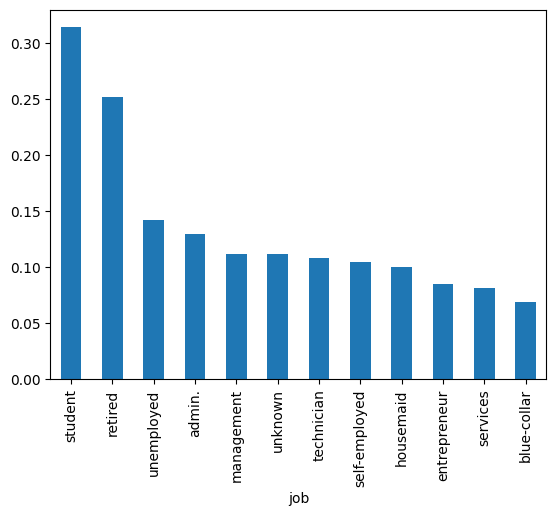

In [8]:
job_conversion = bank_df.groupby('job')['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False)
job_conversion.plot(kind='bar');

Хоча за абсолютною кількістю лідирують адміністратори, аналіз відносної конверсії показує іншу картину:
Студенти (~31%) та пенсіонери (~25%) є найбільш схильними до відкриття депозиту.
Це підтверджує, що модель повинна звертати увагу не на масовість сегменту, а на його специфіку (молодь та літні люди частіше шукають інструменти заощадження).

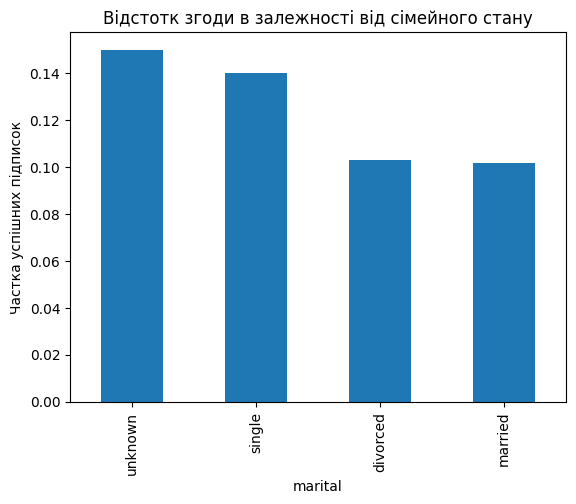

In [9]:
marital_conversion = bank_df.groupby('marital')['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False)
marital_conversion.plot(kind='bar')
plt.title('Відстотк згоди в залежності від сімейного стану')
plt.ylabel('Частка успішних підписок')
plt.show()

Клієнти зі статусом 'single' виявляють вищу схильність до конверсії порівняно з одруженими або розлученими.
Цікавий інсайт: категорія 'unknown' має найвищий відсоток згоди. Це може свідчити про те, що клієнти, які менше надають персональних даних, можуть мати особливий профіль поведінки.
Гіпотеза 3: Сімейний стан 'single' та професії 'student'/'retired' будуть сильними позитивними предикторами для моделі.

## 1.6. Аналіз ознаки pdays та створення was_contacted

In [10]:
bank_df['was_contacted'] = bank_df['pdays'].apply(lambda x: 1 if x != 999 else 0)

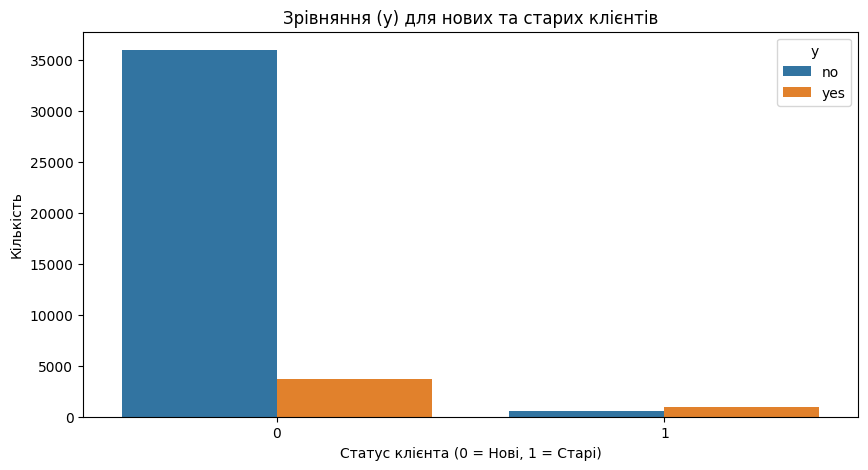

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(bank_df, x='was_contacted', hue='y')
plt.title('Зрівняння (y) для нових та старих клієнтів')
plt.xlabel('Статус клієнта (0 = Нові, 1 = Старі)')
plt.ylabel('Кількість')
plt.show()

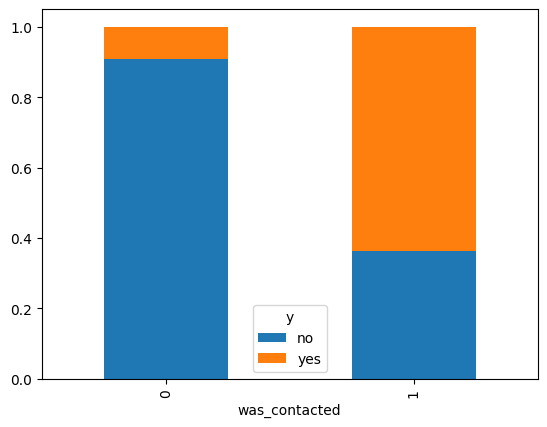

In [12]:
bank_df.groupby('was_contacted')['y'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True);

Ознака pdays (кількість днів з останнього контакту) має специфічне значення 999, яке позначає відсутність попереднього досвіду спілкування з клієнтом.
Було прийнято рішення трансформувати цю ознаку в бінарну змінну was_contacted:
0 — новий клієнт (pdays == 999);
1 — клієнт, з яким вже проводилась робота.

На другому графіку чітко видно, що частка успіху (помаранчевий колір) для "старих" клієнтів перевищує 60%, тоді як для нових вона ледь сягає 10%.
Ця ознака усуває шум від великих числових значень (999) і дає моделі чіткий сигнал про лояльність клієнта.

Висновок: Попередній контакт є одним із найпотужніших факторів впливу. Клієнти, з якими вже був досвід спілкування, погоджуються на пропозицію приблизно в 6 разів частіше.

## 1.7. Аналіз кредитної історії (default) та віку (age)

In [13]:
bank_df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Оскільки категорія yes містить статистично нікчемну кількість даних, ця ознака не зможе суттєво допомогти моделі у класифікації "позитивних" випадків. Однак ми залишаємо її в наборі, оскільки статус unknown може нести певну приховану інформацію про клієнта.

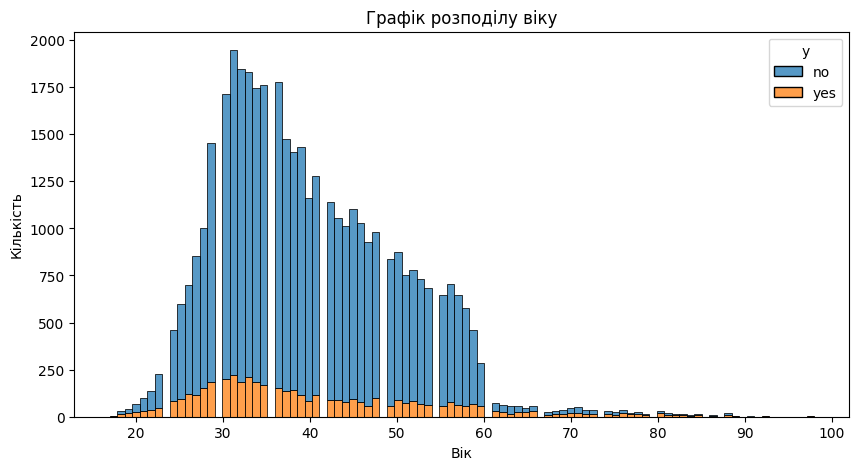

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(bank_df, x='age', hue='y', multiple='stack')
plt.title('Графік розподілу віку')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.show()


Графік розподілу віку підтверджує нашу попередню гіпотезу щодо професій (студенти та пенсіонери):
Основна маса клієнтів: Знаходиться в діапазоні 30-45 років.
"U-подібна" залежність: Ми бачимо, що помаранчева частка (yes) значно зростає у молоді до 25 років та різко збільшується у людей старше 60 років.

Висновок: Вік є нелінійною ознакою. Моделі деревних алгоритмів XGBoost/LightGBM чудово впораються з такими порогами.

## 1.8. Вплив зовнішніх та сезонних факторів

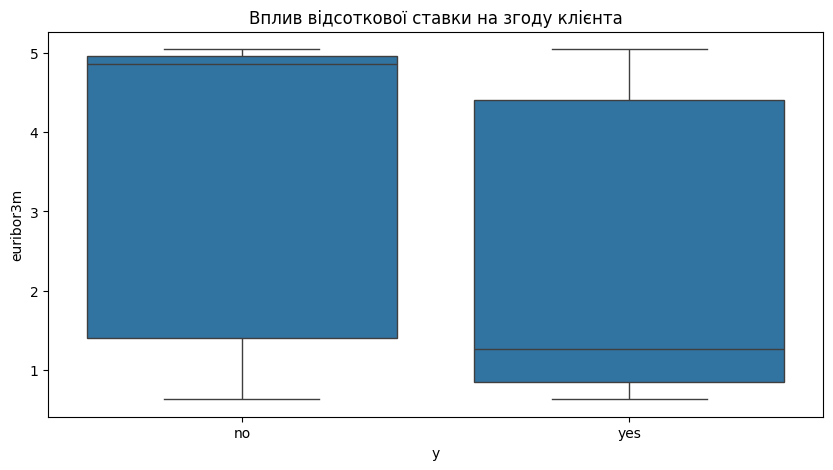

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(bank_df, x='y', y='euribor3m')
plt.title('Вплив відсоткової ставки на згоду клієнта')
plt.show()

На боксплоті чітко видно, що медіанна ставка Euribor для тих, хто погодився (yes), значно нижча (близько 1.3%), ніж для тих, хто відмовився (близько 4.8%).

Висновок: Клієнти набагато охочіше відкривають депозити, коли міжбанківські ставки низькі. Це може бути пов'язано з фазами економічного циклу або агресивністю маркетингу банку в ці періоди.

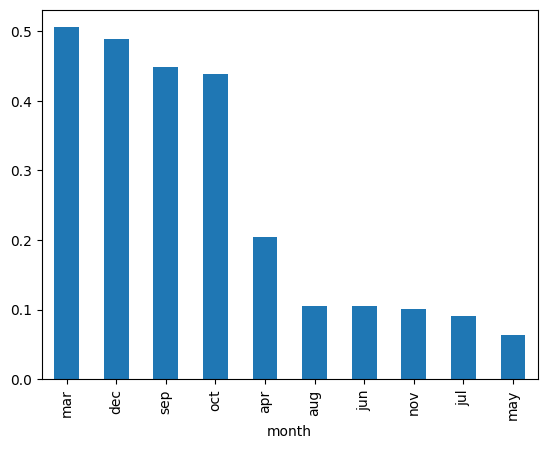

In [16]:
month_conversion = bank_df.groupby('month')['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False)
month_conversion.plot(kind='bar');

Лідери: Березень, грудень, вересень та жовтень показують аномально високий відсоток згоди (до 50%).
Провал: Травень — наймасовіший місяць за кількістю дзвінків, але з найнижчою ефективністю.

Висновок: Модель обов'язково має враховувати фактор місяця, оскільки це вказує на сезонні маркетингові цикли.

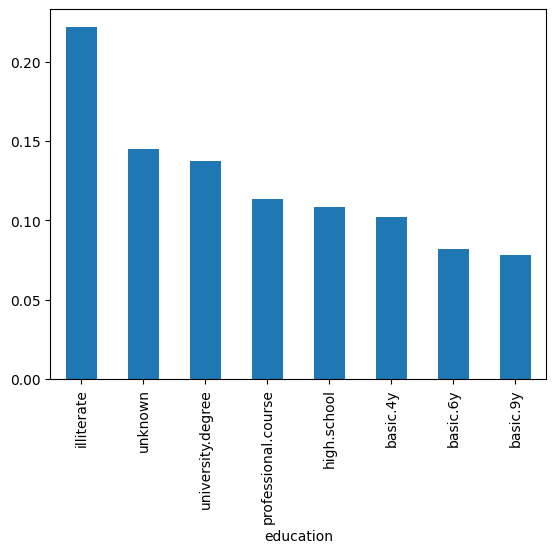

In [17]:
education_conversion = bank_df.groupby('education')['y'].value_counts(normalize=True).unstack()['yes'].sort_values(ascending=False)
education_conversion.plot(kind='bar');

In [18]:
bank_df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Клієнти з вищою освітою (university.degree) є більш лояльними до банківських продуктів.
Цікавий випадок з категорією illiterate: вони мають найвищий відсоток згоди, але через їхню малу кількість (лише 18 осіб) цей показник може бути статистично нестійким.

## 1.9. Аналіз інтенсивності кампанії (campaign)

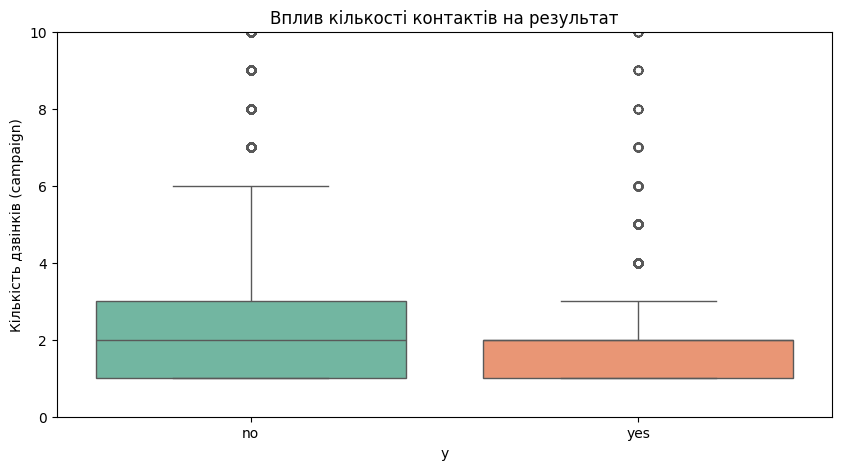

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=bank_df, x='y', y='campaign', palette='Set2')
plt.ylim(0, 10) 
plt.title('Вплив кількості контактів на результат')
plt.ylabel('Кількість дзвінків (campaign)')
plt.show()

Медіанна кількість дзвінків для успішних кейсів (yes) є нижчою, ніж для відмов. Більшість успішних підписок відбувається протягом перших 2-3 контактів.

Висновок: Після 5-6 невдалого дзвінка ймовірність того, що клієнт погодиться, стрімко падає. Надмірна кількість дзвінків ("тиск" на клієнта) не приносить результату і лише збільшує витрати банку.

## 1.10. Тип зв'язку та день тижня

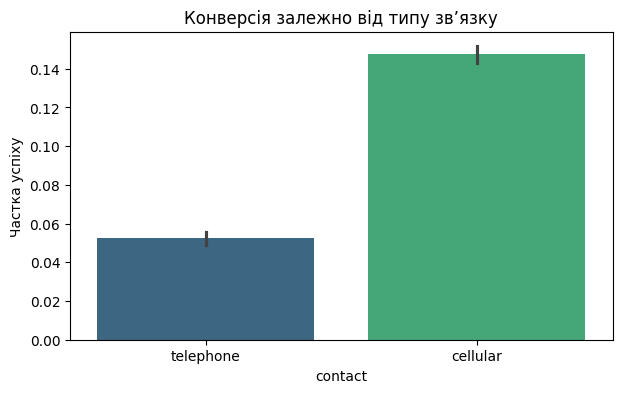

In [20]:
plt.figure(figsize=(7, 4))
sns.barplot(x=bank_df['contact'], y=(bank_df['y'] == 'yes').astype(int), palette='viridis')
plt.title('Конверсія залежно від типу зв’язку')
plt.ylabel('Частка успіху')
plt.show()

Використання мобільних телефонів (cellular) показує значно вищу ефективність порівняно зі стаціонарними (telephone). Це логічно, оскільки мобільний телефон забезпечує більш персоналізований та прямий доступ до клієнта.

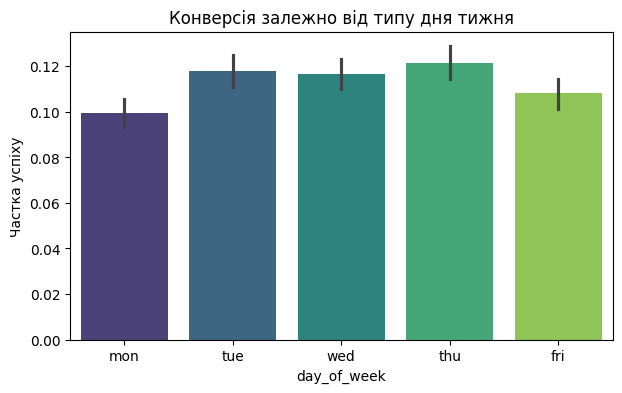

In [21]:
plt.figure(figsize=(7, 4))
sns.barplot(x=bank_df['day_of_week'], y=(bank_df['y'] == 'yes').astype(int), palette='viridis')
plt.title('Конверсія залежно від типу дня тижня')
plt.ylabel('Частка успіху')
plt.show()

Попередній аналіз не виявив критичної різниці між днями тижня, що свідчить про рівномірну ефективність роботи кол-центру протягом робочого тижня.

## 1.11. Кореляційний аналіз та мультиколінеарність

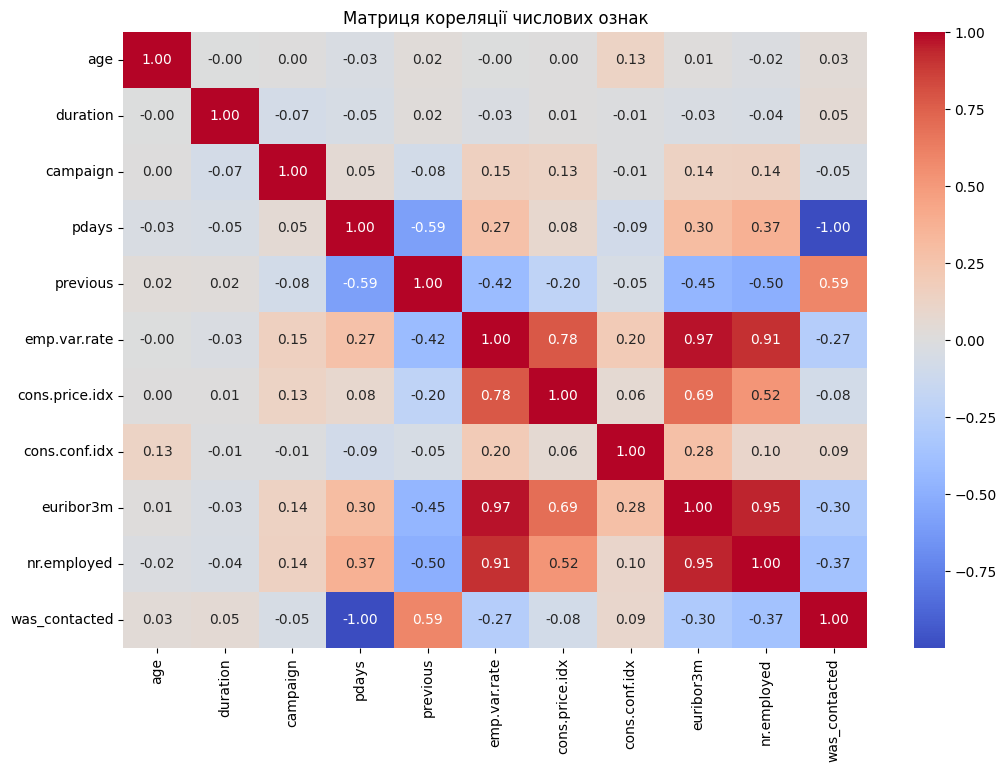

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(bank_df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляції числових ознак')
plt.show()

Ми бачимо екстремально високу кореляцію між euribor3m, emp.var.rate (0.97) та nr.employed (0.95).
Проблема: Ці ознаки майже ідентичні. Використання їх усіх одночасно призведе до нестабільності ваг у логістичній регресії.

Рішення: Для навчання лінійних моделей варто залишити лише одну з них (наприклад, euribor3m), оскільки вона має найбільш плавну динаміку.

## 1.12. Аналіз викидів (Outliers)

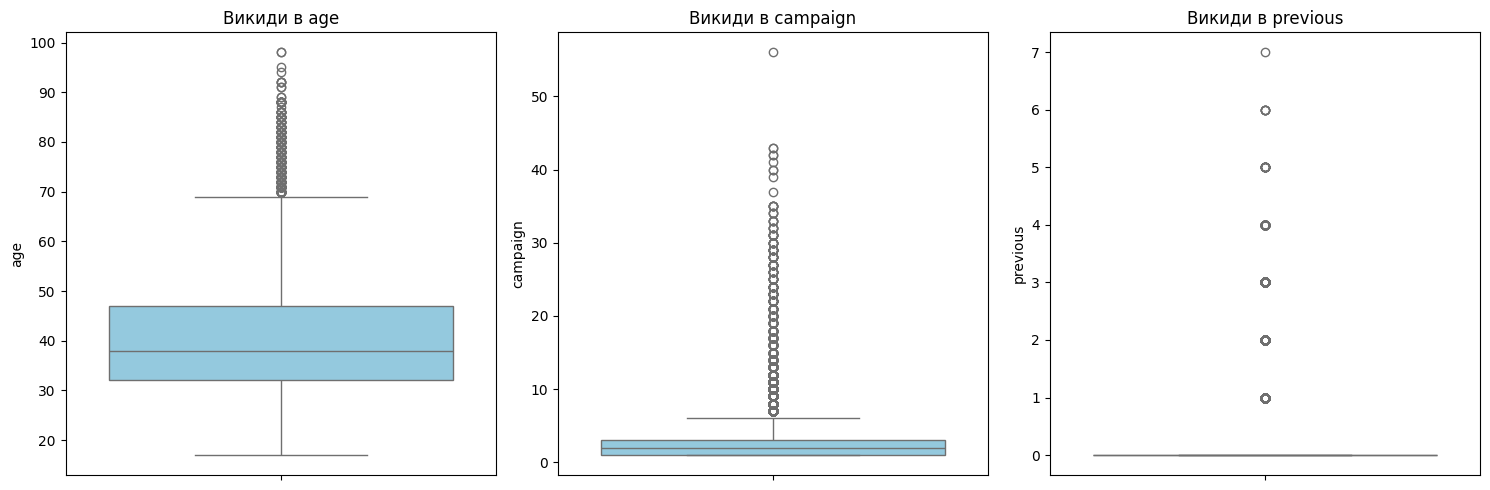

In [23]:
num_features = ['age', 'campaign', 'previous']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=bank_df[col], color='skyblue')
    plt.title(f'Викиди в {col}')

plt.tight_layout()
plt.show()

Аналіз викидів за допомогою Boxplot виявив аномально високі значення в колонках age та campaign. Однак, було прийнято рішення не видаляти ці записи, оскільки вони представляють реальні (хоч і рідкісні) бізнес-кейси. Зокрема, старша вікова група є найбільш лояльною, а висока інтенсивність дзвінків у campaign відображає реальну активність колл-центрів.

### Загальний висновок EDA

Найвищу схильність до відкриття депозиту демонструють студенти та пенсіонери, клієнти з вищою освітою, а також ті, хто вже мав успішний досвід співпраці з банком у минулому.

Низька відсоткова ставка euribor3m та сезонність (березень, вересень) критично підвищують шанси на успіх.

Виявлено високу мультиколінеарність економічних показників, що вимагає видалення emp.var.rate та nr.employed. Ознаку duration буде вилучено для запобігання "data leakage".

# 2. Методи та метрика

Методи, які доречно використовувати:

Logistic Regression: Як базовий лінійний алгоритм (Baseline) для перевірки лінійних залежностей.

Decision Tree: Для розуміння логіки прийняття рішень та обробки нелінійних зв'язків.

k-Nearest Neighbors: Непараметричний метод, що базується на обчисленні відстаней між об'єктами..

LGBM: Як найсучасніший та найпотужніший метод, що працює з ансамблями дерев. Він обраний через здатність автоматично обробляти пропуски, категоріальні дані та високу стійкість до перенавчання.

Для оцінки якості моделей було обрано комбінований підхід, проте основною бізнес-метрикою визначено F1-score.

Дисбаланс класів: У нашому наборі даних спостерігається значний дисбаланс (лише ~11% позитивних результатів). У таких умовах метрика Accuracy є неінформативною, оскільки модель може ігнорувати міноритарний клас і все одно мати високий показник точності.

Баланс між Precision та Recall: Для банку однаково важливо не витрачати ресурси на холості дзвінки тим, хто не відкриє депозит (Precision), і водночас не втратити потенційних клієнтів (Recall). F1-score є гармонійним середнім між цими двома показниками, що дозволяє оптимізувати модель під реальні потреби бізнесу.

ROC AUC як додатковий контроль: Ми також використовуємо ROC AUC для оцінки загальної здатності моделі розділяти класи незалежно від обраного порогу, що дає впевненість у стабільності алгоритму.

# 3. Підготовка даних (Preprocessing)

In [24]:
for col in bank_df.select_dtypes(include='object').columns:
    count = (bank_df[col] == 'unknown').sum()
    print(f"{col}: {count} unknowns")

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns
contact: 0 unknowns
month: 0 unknowns
day_of_week: 0 unknowns
poutcome: 0 unknowns
y: 0 unknowns


Під час аналізу категоріальних змінних було виявлено значну кількість значень unknown (особливо в default — 8597 записів). Оскільки ці пропуски можуть нести приховану інформацію, було прийнято рішення не видаляти їх і не імпютувати, а трактувати як окрему категорію за допомогою One-Hot Encoding.

In [25]:
bank_df['y'] = bank_df['y'].map({'yes': 1, 'no': 0})
cols_to_drop = ['duration', 'emp.var.rate', 'nr.employed', 'pdays']
bank_df = bank_df.drop(columns=cols_to_drop)
target_col = 'y'
input_cols = bank_df.columns.drop(target_col).to_list()
train_df, test_df = train_test_split(bank_df, test_size=0.2, random_state=42, stratify=bank_df['y'])
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
test_inputs, test_targets = test_df[input_cols].copy(), test_df[target_col].copy()
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

scaler = StandardScaler().fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

train_inputs = train_inputs.drop(columns=categorical_cols)
test_inputs = test_inputs.drop(columns=categorical_cols)

Feature Selection: Вилучено ознаки з високою мультиколінеарністю (emp.var.rate, nr.employed) та ознаку duration для запобігання витоку даних. Оригінальна ознака pdays також була видалена, оскільки на етапі EDA ми трансформували її в більш інформативну бінарну змінну was_contacted. Це дозволило позбутися специфічного значення 999, яке могло спотворити роботу лінійних моделей.

Target Transformation: Цільову змінну y перетворено у бінарний формат (0 та 1).

Train-Test Split: Дані розділено у співвідношенні 80/20 зі стратифікацією за цільовою змінною для збереження балансу класів.

Encoding: Категоріальні змінні оброблено за допомогою OneHotEncoder. Значення unknown залишено як окремі категорії.

Scaling: Використано StandardScaler для всіх ознак після One-Hot Encoding. Хоча для деревних моделей (XGBoost/LGBM) це не є обов'язковим, це забезпечує коректну роботу лінійних моделей та kNN в нашому порівняльному аналізі.

Feature Engineering & Selection: Було проведено серію експериментів із просунутим інжинірингом ознак (Target Encoding для job, month, poutcome). Однак, фінальне тестування показало, що базовий набір ознак у поєднанні з бінарною ознакою was_contacted (похідна від pdays) забезпечує вищу стабільність моделі та кращий показник F1 на тестовій вибірці. Тому було вирішено залишити лаконічну модель, щоб уникнути перенавчання (overfitting).

# 4. Моделі машинного навчання

## Функції для зручності обчислення

In [26]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_probs = model.predict_proba(X_train)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    print('ROC_AUC Train:', round(roc_auc_score(y_train, train_probs), 4))
    print('ROC_AUC Test:', round(roc_auc_score(y_test, test_probs), 4))
    print('\nClassification Report Train:\n', classification_report(y_train, train_preds))
    print('\nClassification Report Test:\n', classification_report(y_test, test_preds))

In [27]:
def plot_train_test_matrix(model, X_train, y_train, X_test, y_test, labels=None):
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ConfusionMatrixDisplay.from_estimator(
    model, X_train, y_train, display_labels=labels, cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix: Train')

    ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=labels, cmap='Reds', ax=ax[1])
    ax[1].set_title('Confusion Matrix: Test')

    plt.tight_layout()
    plt.show()

In [28]:
def plot_curves(model, X_train, y_train, X_test, y_test):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    RocCurveDisplay.from_estimator(model, X_train, y_train, ax=ax1, name='Train')
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1, name='Test')
    ax1.set_title('ROC Curve: Train vs Test')
    
    PrecisionRecallDisplay.from_estimator(model, X_train, y_train, ax=ax2, name='Train')
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2, name='Test')
    ax2.set_title('PR Curve: Train vs Test')
    
    plt.show()

In [29]:
def find_best_threshold(model, X_test, y_test):

    probabilities = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, probabilities)
    
    f1_scores = 2 * (precision * recall) / (precision + recall)
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    print(f'Threshold (0.5) ')
    print(classification_report(y_test, (probabilities >= 0.5).astype(int)))
    
    print(f'threshold ({best_threshold:.2f})')
    print(classification_report(y_test, (probabilities >= best_threshold).astype(int)))
    return best_threshold

In [30]:
def plot_feature_importance(model, features, top_n=10):
    importance_df = pd.DataFrame({
        'features': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='features', data=importance_df.head(top_n))
    plt.title(f'Top {top_n} important features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    return importance_df

## 4.1. LogisticRegression

In [31]:
log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg.fit(train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [32]:
evaluate_model(log_reg, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.793
ROC_AUC Test: 0.7993

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.85      0.89     29238
           1       0.34      0.63      0.44      3712

    accuracy                           0.82     32950
   macro avg       0.64      0.74      0.67     32950
weighted avg       0.88      0.82      0.84     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



In [33]:
weights_df = pd.DataFrame({
    'feature': np.append(train_inputs.columns, 'intercept'),
    'weight': np.append(log_reg.coef_[0], log_reg.intercept_[0])
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
47,month_mar,1.033855
50,month_oct,0.490150
27,education_illiterate,0.487596
44,month_dec,0.346065
12,job_retired,0.343170
...,...,...
51,month_sep,-0.307400
57,poutcome_failure,-0.321325
33,default_yes,-0.322988
48,month_may,-0.826097


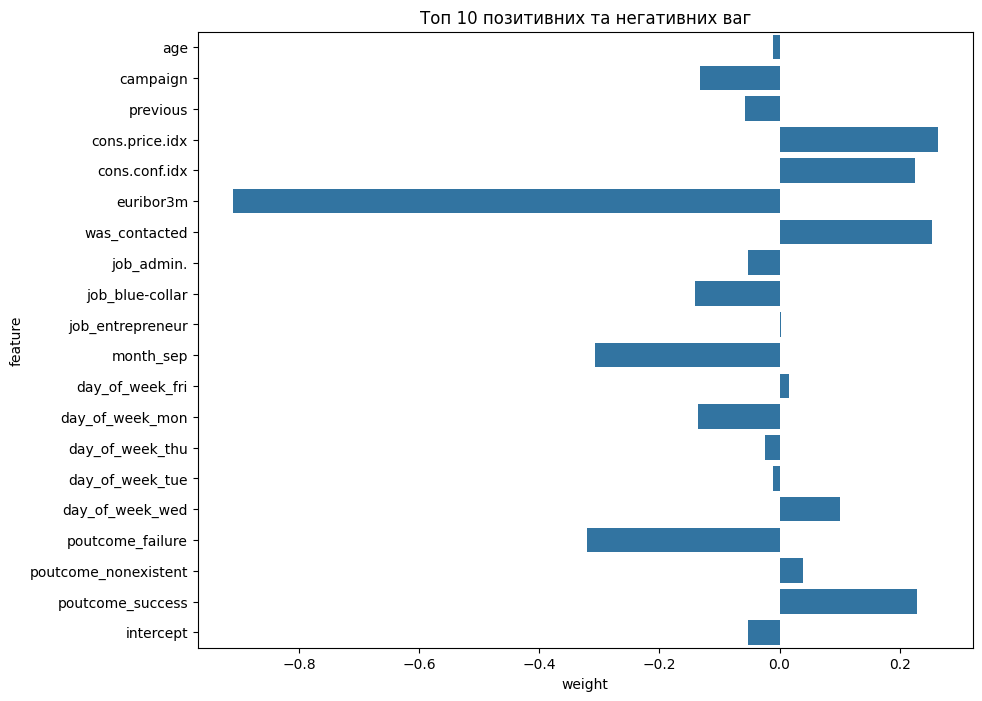

In [34]:
top_weights = pd.concat([weights_df.head(10), weights_df.tail(10)])
plt.figure(figsize=(10, 8))
sns.barplot(data=top_weights, x='weight', y='feature')
plt.title('Топ 10 позитивних та негативних ваг')
plt.show()

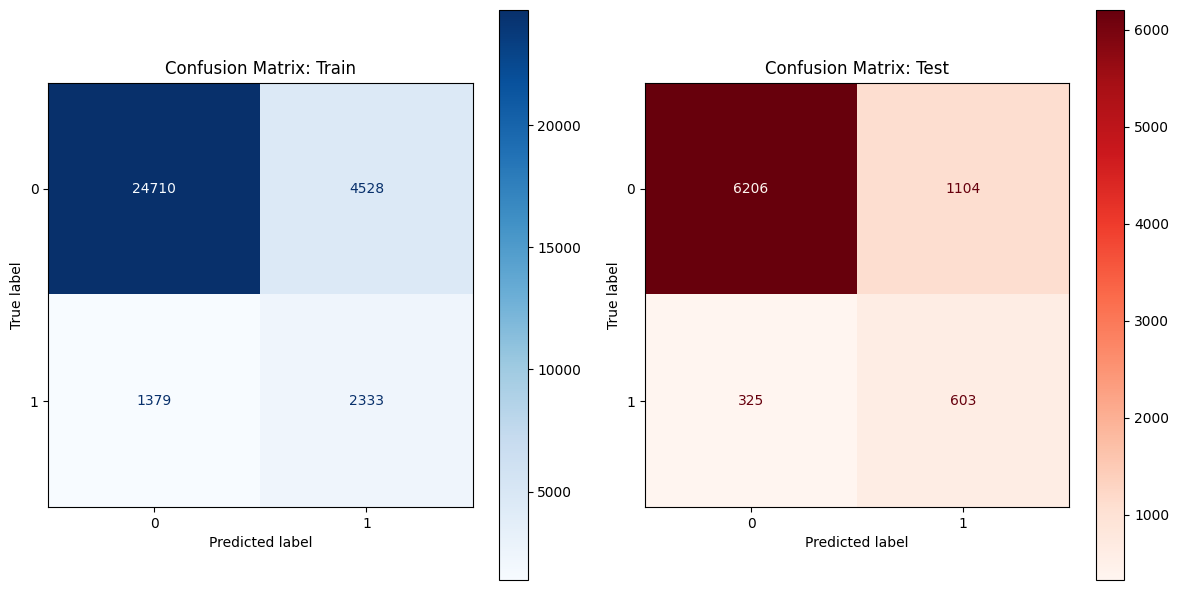

In [35]:
plot_train_test_matrix(log_reg, train_inputs, train_targets, test_inputs, test_targets)

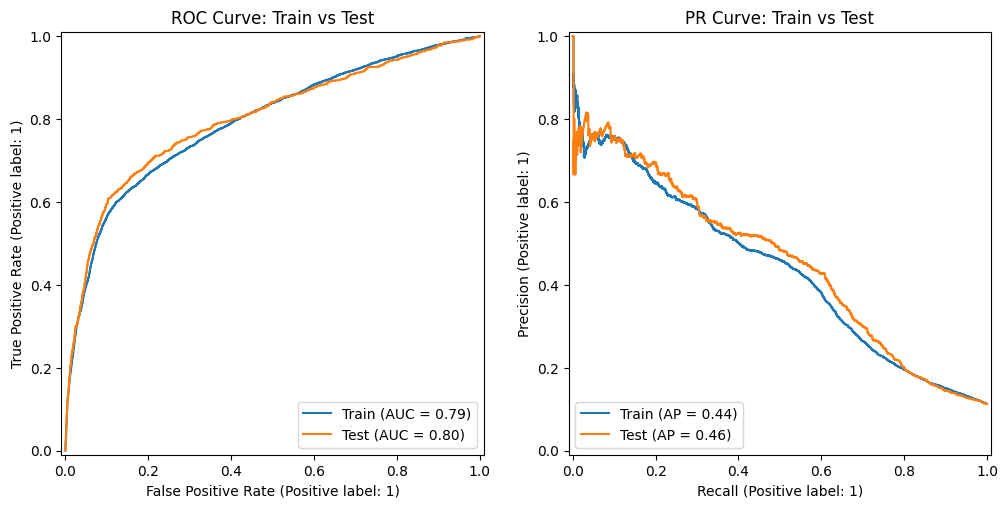

In [36]:
plot_curves(log_reg, train_inputs, train_targets, test_inputs, test_targets)

In [37]:
find_best_threshold(log_reg, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

threshold (0.62)
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7310
           1       0.43      0.61      0.50       928

    accuracy                           0.86      8238
   macro avg       0.69      0.75      0.71      8238
weighted avg       0.89      0.86      0.87      8238



np.float64(0.61545753690522)

Показник ROC AUC 0.7993 на тестовій вибірці свідчить про високу здатність моделі відрізняти потенційних вкладників від відмов. Різниця між Train та Test мінімальна, що вказує на відсутність перенавчання.

Завдяки балансуванню ваг, модель успішно ідентифікує 65% реальних підписок (Recall для класу 1). Для банку це означає можливість охопити більшість цільової аудиторії, хоч і ціною зниження Precision (35%).

На тестовій вибірці модель правильно визначила 603 підписки, але припустилася 1104 помилкових викликів (False Positive). Це компроміс для маркетингової кампанії, де вартість дзвінка значно нижча за прибуток від нового депозиту.

ROC Curve: Крива впевнено тягнеться до лівого верхнього кута, що підтверджує стабільність моделі незалежно від обраного порогу ймовірності

Feature Importance:

Найсильніший позитивний вплив мають березень (month_mar), жовтень (month_oct) та успіх попередньої кампанії (poutcome_success). Також важливими є фактори неграмотності (хоча група мала, вона схильна довіряти банку) та пенсійний статус.

Головним "стоп-фактором" є відсоткова ставка euribor3m (вага -0.91) та травень (month_may). Висока ставка Euribor зазвичай корелює з нестабільністю, що змушує клієнтів притримувати готівку замість довгострокових депозитів.

Зміна порогу з 0.5 до 0.62 дозволила підвищити точність (Precision) з 0.35 до 0.43, що суттєво зменшило кількість марних дзвінків. Хоча повнота (Recall) дещо знизилася, підсумковий F1-score зріс з 0.46 до 0.50, зробивши модель більш збалансованою та ефективною для бізнес-задачі.

Висновок: Модель демонструє адекватну логіку та стабільні результати. Вона слугуватиме надійним орієнтиром для порівняння з більш складними нелінійними алгоритмами (kNN, Decision Tree, LGBM).

## 4.2. KNNClassifier

In [38]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(train_inputs, train_targets)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [39]:
evaluate_model(knn, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.9259
ROC_AUC Test: 0.744

Classification Report Train:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     29238
           1       0.71      0.38      0.49      3712

    accuracy                           0.91     32950
   macro avg       0.82      0.68      0.72     32950
weighted avg       0.90      0.91      0.90     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.59      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



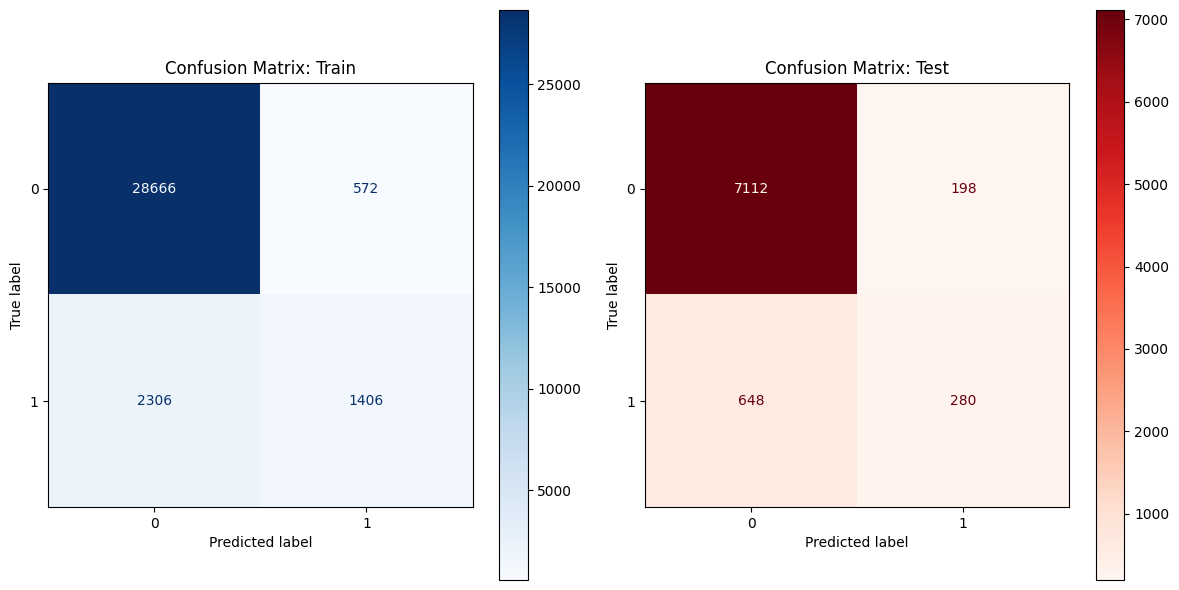

In [40]:
plot_train_test_matrix(knn, train_inputs, train_targets, test_inputs, test_targets)

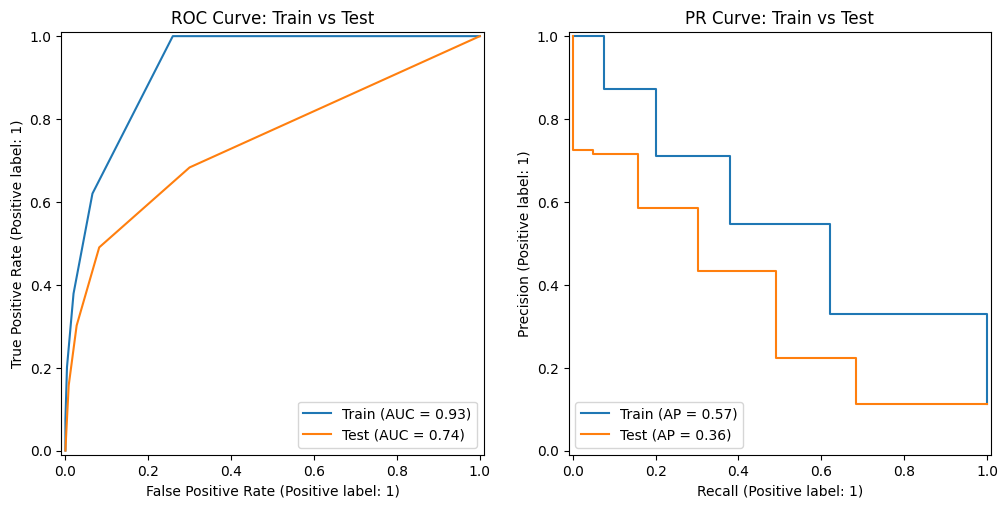

In [41]:
plot_curves(knn, train_inputs, train_targets, test_inputs, test_targets)

In [42]:
find_best_threshold(knn, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.59      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238

threshold (0.40)
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7310
           1       0.43      0.49      0.46       928

    accuracy                           0.87      8238
   macro avg       0.68      0.70      0.69      8238
weighted avg       0.88      0.87      0.87      8238



np.float64(0.4)

Показник ROC AUC на тесті (0.744) значно нижчий за Train (0.926). На графіку ROC-кривої ми бачимо сильний розрив, що є прямим доказом overfitting.

kNN поступається перед дисбалансом класів. Оскільки він шукає 5 найближчих сусідів, у 70% випадків серед них виявляються лише представники більшості (клас "no").

Зниження порогу з 0.5 до 0.40 дозволило значно покращити повноту (Recall) з 0.30 до 0.49, що допомогло моделі виявляти майже половину потенційних клієнтів замість третини. Попри очікуване зниження точності (Precision), такий підхід забезпечив зростання F1-score з 0.40 до 0.46, зробивши прогноз більш корисним для охоплення цільової аудиторії.

Висновок: kNN продемонстрував найгірший результат серед протестованих моделей. Він занадто складний в обчисленнях (через пошук відстаней) і при цьому менш точний за базову регресію.

## 4.3. DecisionTreeClassifier

In [43]:
dtc = DecisionTreeClassifier(
    random_state=42, 
    max_depth=10, 
    max_leaf_nodes=20, 
    class_weight='balanced'
)
dtc.fit(train_inputs, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",20
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [44]:
evaluate_model(dtc, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.7939
ROC_AUC Test: 0.7995

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89     29238
           1       0.34      0.66      0.45      3712

    accuracy                           0.82     32950
   macro avg       0.65      0.75      0.67     32950
weighted avg       0.88      0.82      0.84     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.84      0.90      7310
           1       0.36      0.68      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.76      0.68      8238
weighted avg       0.89      0.83      0.85      8238



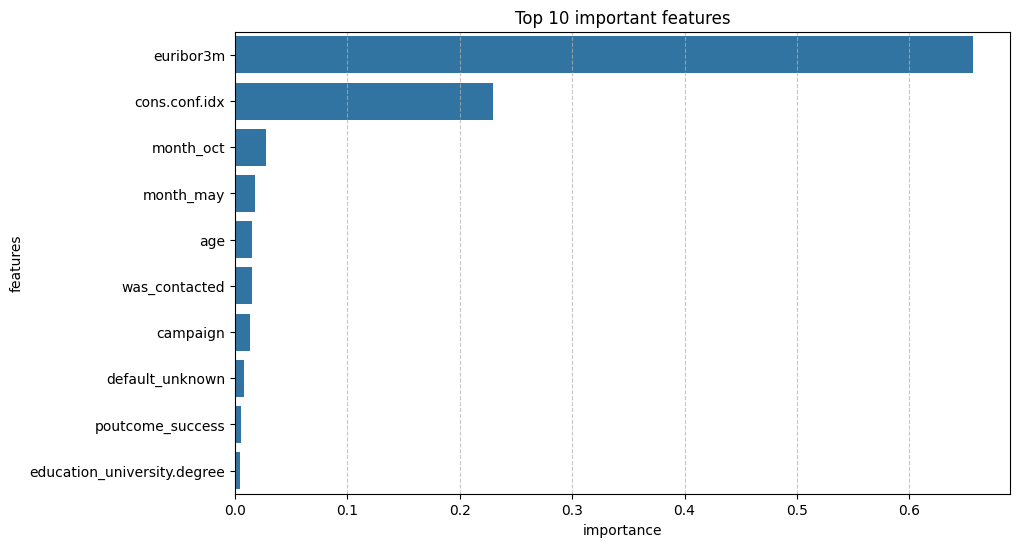

,features,importance
5,euribor3m,0.656845
4,cons.conf.idx,0.229570
50,month_oct,0.027696
48,month_may,0.018027
0,age,0.014884
6,was_contacted,0.014859
1,campaign,0.013030
32,default_unknown,0.007896
59,poutcome_success,0.005177
29,education_university.degree,0.004687


In [45]:
plot_feature_importance(dtc, train_inputs.columns)

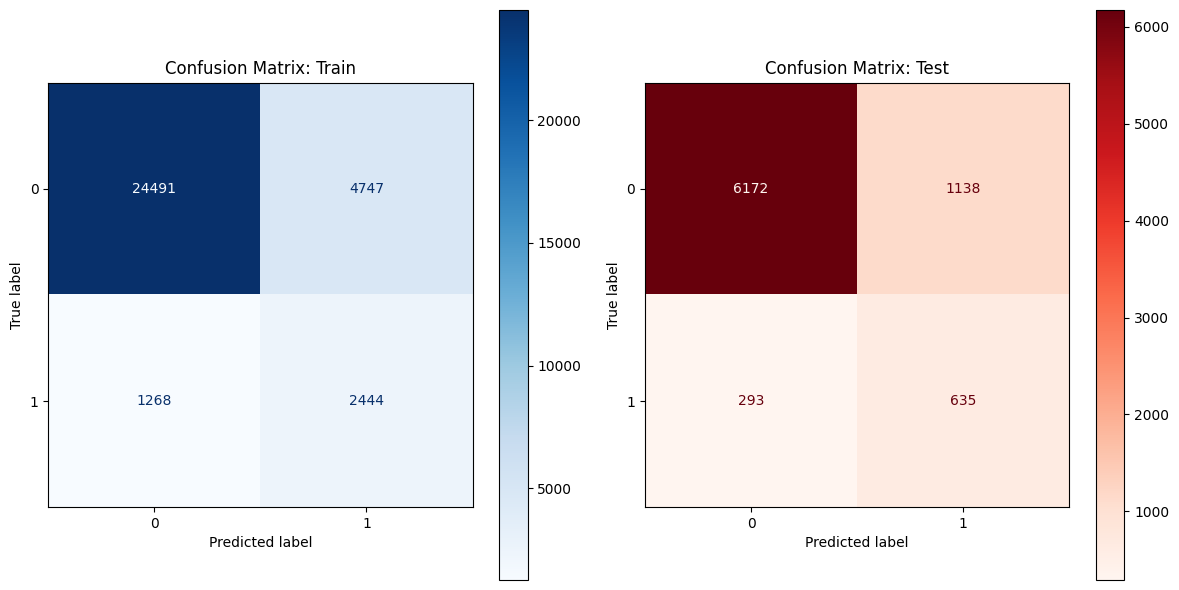

In [46]:
plot_train_test_matrix(dtc, train_inputs, train_targets, test_inputs, test_targets)

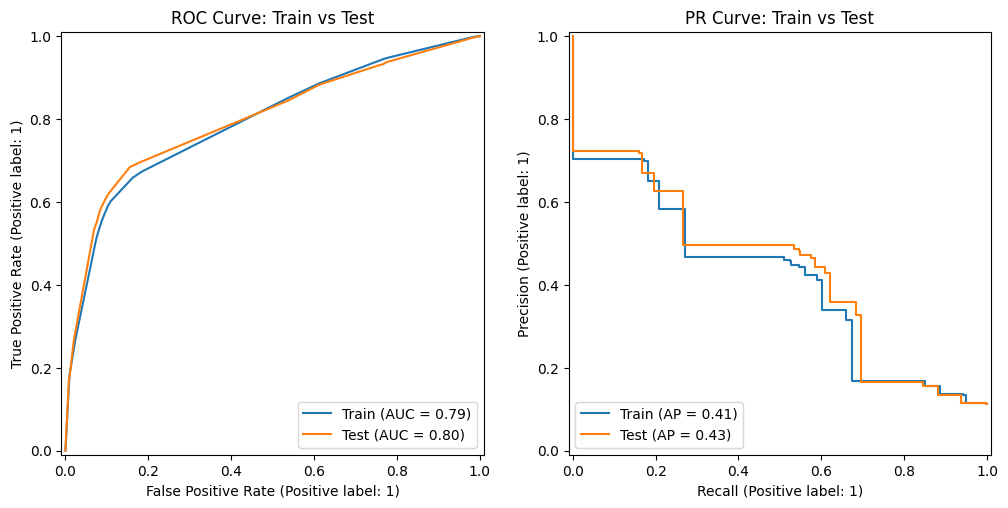

In [47]:
plot_curves(dtc, train_inputs, train_targets, test_inputs, test_targets)

In [48]:
find_best_threshold(dtc, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.84      0.90      7310
           1       0.36      0.68      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.76      0.68      8238
weighted avg       0.89      0.83      0.85      8238

threshold (0.74)
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.59      0.52       928

    accuracy                           0.88      8238
   macro avg       0.70      0.75      0.72      8238
weighted avg       0.89      0.88      0.88      8238



np.float64(0.7401044623227971)

Для побудови дерева було використано обмеження глибини (max_depth=10) та кількості листків, щоб запобігти перенавчанню, а також параметр class_weight='balanced' для коректної роботи з дисбалансом.

Модель продемонструвала найкращий показник F1-score (0.47) на тестовій вибірці серед усіх попередніх алгоритмів. Показник ROC AUC (0.7995) підтверджує стабільність моделі та відсутність перенавчання (результати на Train та Test майже ідентичні).

Завдяки зважуванню класів, дерево досягло високого рівня Recall (0.68), що дозволяє банку ідентифікувати 68% потенційних клієнтів.

Модель правильно визначила 635 підписок на тесті, що є кращим результатом, ніж у логістичної регресії (603) та kNN (280).

Графік feature_importances_ чітко вказує на домінуючі фактори:

euribor3m (65.6%): Тримісячна процентна ставка є ключовим розділювачем. Це логічно: макроекономічні умови визначають готовність людей до інвестування.

cons.conf.idx (22.9%): Індекс споживчої довіри займає друге місце, що підкреслює вплив психологічного стану ринку на успіх депозитів.

month_oct & month_may: Сезонність залишається важливим фактором, що підтверджує висновки з EDA.

Підняття порогу до 0.74 дозволило суттєво покращити точність (Precision) з 0.36 до 0.46, що значно мінімізує кількість дзвінків нецільовим клієнтам. Попри очікуване зниження повноти (Recall), модель стала більш вибірковою, що забезпечило зростання F1-score до 0.52 — одного з найвищих показників серед базових моделей

Висновок: Дерево рішень показало себе як проста, але дуже ефективна модель. Вона забезпечує кращу виявність клієнтів за kNN і є більш інтерпретованою за логістичну регресію, хоча приріст якості порівняно з останньою є незначним.

## 4.4. LGBMClassifier (Gradient Boosting)

In [49]:
ratio = float(train_targets.value_counts()[0] / train_targets.value_counts()[1])
lgb_model = LGBMClassifier(
    max_depth=6,
    n_estimators=150,
    learning_rate=0.03,
    num_leaves=14,
    scale_pos_weight=ratio,
    random_state = 42,
    importance_type='gain',
    verbosity=-1
)

lgb_model.fit(train_inputs, train_targets)

,boosting_type,'gbdt'
,num_leaves,14
,max_depth,6
,learning_rate,0.03
,n_estimators,150
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [50]:
evaluate_model(lgb_model, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.82
ROC_AUC Test: 0.8154

Classification Report Train:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90     29238
           1       0.37      0.65      0.47      3712

    accuracy                           0.83     32950
   macro avg       0.66      0.75      0.69     32950
weighted avg       0.89      0.83      0.85     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.86      0.91      7310
           1       0.38      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238



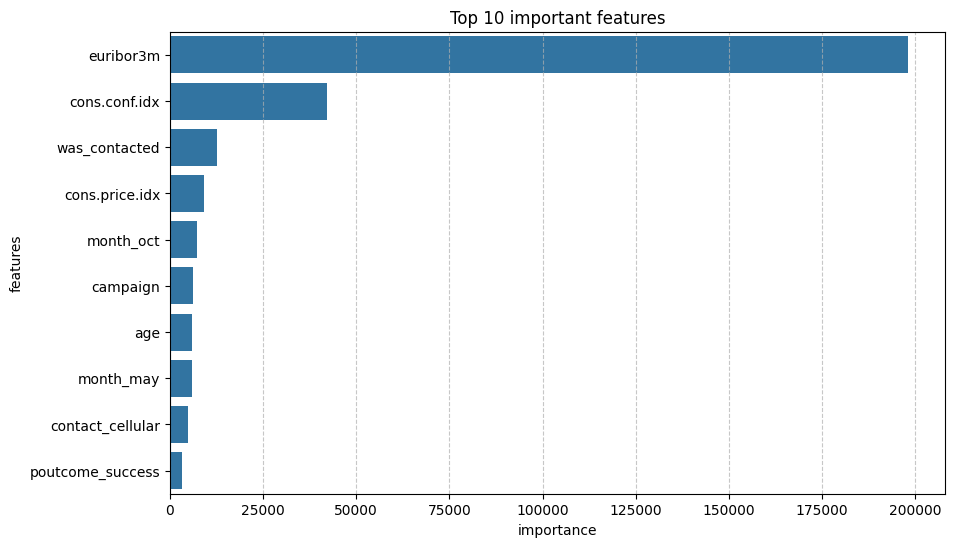

,features,importance
5,euribor3m,198030.293242
4,cons.conf.idx,42093.785270
6,was_contacted,12551.163251
3,cons.price.idx,9280.551374
50,month_oct,7397.323508
1,campaign,6136.811328
0,age,6029.817677
48,month_may,5831.383481
40,contact_cellular,4815.609004
59,poutcome_success,3330.113992


In [51]:
plot_feature_importance(lgb_model, train_inputs.columns)

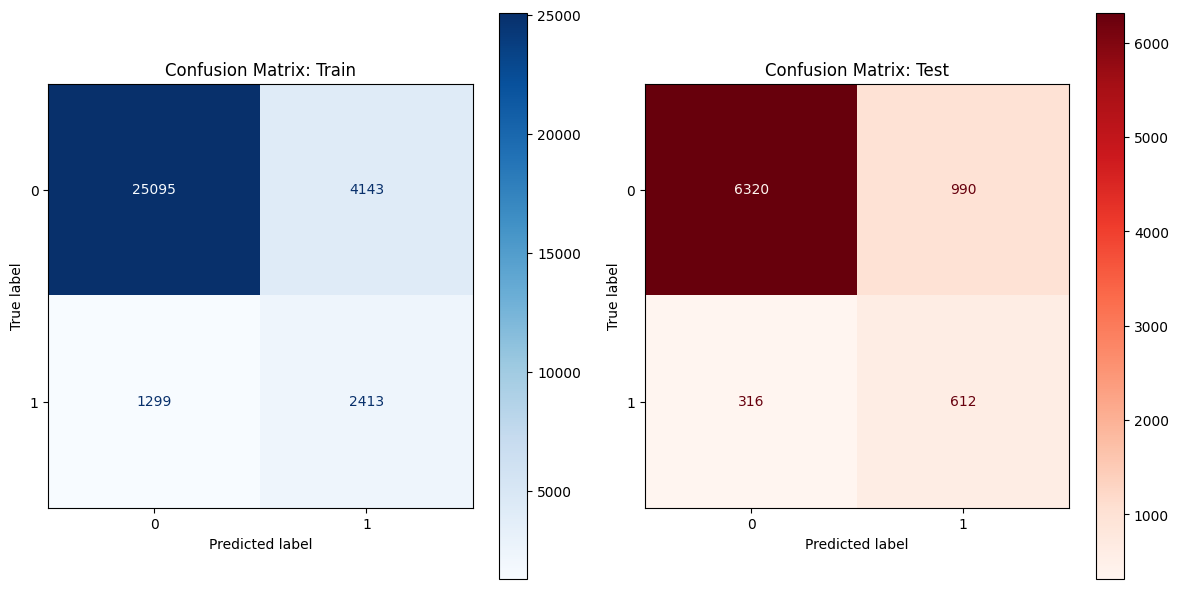

In [52]:
plot_train_test_matrix(lgb_model, train_inputs, train_targets, test_inputs, test_targets)

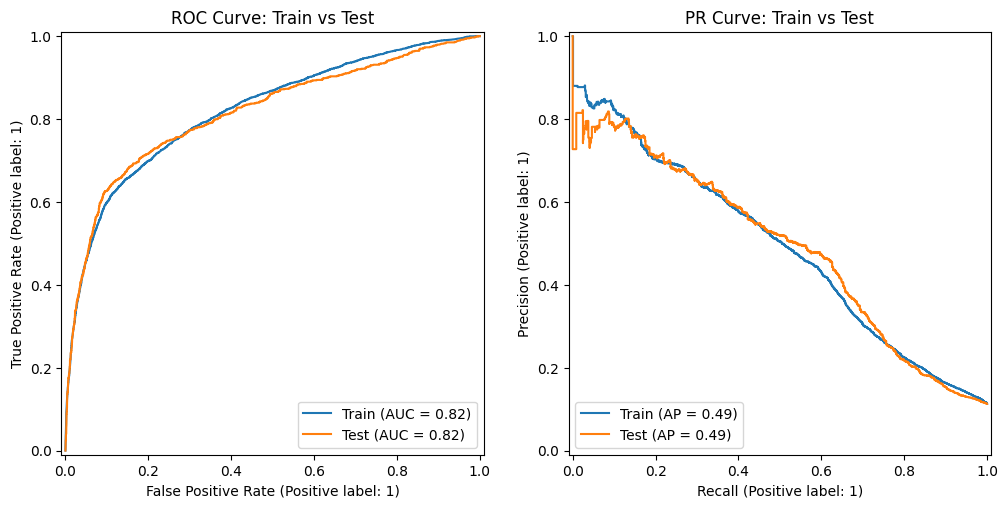

In [53]:
plot_curves(lgb_model, train_inputs, train_targets, test_inputs, test_targets)

In [54]:
find_best_threshold(lgb_model, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7310
           1       0.38      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

threshold (0.67)
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238



np.float64(0.6712033752889267)

Це найбільш просунута модель у нашому дослідженні, яка використовує ансамбль дерев рішень.

Модель досягла ROC AUC 0.8154 та найкращого показника F1-score (0.48). Це означає, що бустинг зміг знайти складніші закономірності, ніж поодиноке дерево чи регресія. Результати на Train (0.82) та Test (0.815) майже ідентичні. Завдяки параметрам max_depth=6 та num_leaves=14 ми повністю уникли перенавчання.

Баланс Recall 0.66 / Precision 0.38: Модель демонструє дуже впевнену здатність знаходити цільових клієнтів.

Показники euribor3m та cons.conf.idx є вирішальними для успіху кампанії.

Клієнти, з якими вже був успішний контакт раніше (was_contacted, poutcome_success), мають значно вищий шанс погодитися на депозит.

Березень та жовтень — "золоті" місяці для маркетингу, тоді як травень — найбільш невдалий.

Оптимізація порогу до 0.67 дозволила значно підвищити точність (Precision) з 0.38 до 0.48, що суттєво зменшує витрати на неефективні дзвінки. Завдяки цьому F1-score зріс з 0.48 до 0.53, забезпечуючи моделі кращий баланс між виявленням зацікавлених клієнтів та якістю прогнозів навіть без додаткового тюнінгу гіперпараметрів.

Бізнес-рекомендація: Використовувати модель LGBM для пріоритезації дзвінків. Це дозволить банку охопити 66% потенційних вкладників, відсіюючи при цьому понад 85% тих, хто точно відмовить, що значно зекономить бюджет на кол-центр.

# 5. Таблиця з порівнянням якості моделей

In [55]:
def get_metrix(model, train_inputs, train_targets, test_inputs, test_targets, model_name, comments):
    return {
        'Model': model_name,
        'Hyperparams': str(model.get_params())[:150],
        'ROC_AUC Train': round(roc_auc_score(train_targets, model.predict_proba(train_inputs)[:, 1]), 4),
        'ROC_AUC Test': round(roc_auc_score(test_targets, model.predict_proba(test_inputs)[:, 1]), 4),
        'F1 score Train': round(f1_score(train_targets, model.predict(train_inputs)), 4),
        'F1 score Test': round(f1_score(test_targets, model.predict(test_inputs)), 4),
        'Precision Test': round(precision_score(test_targets, model.predict(test_inputs)), 4),
        'Recall Test': round(recall_score(test_targets, model.predict(test_inputs)), 4),
        'Comment': comments
    }

In [56]:
all_results = []

all_results.append(get_metrix(log_reg, train_inputs, train_targets, test_inputs, test_targets,
                              'Logistic Regression',
                              'Стабільна модель, результати на трейні та тесті близькі. Можна використовувати як baseline'))
all_results.append(get_metrix(knn, train_inputs, train_targets, test_inputs, test_targets, 
                              'kNN',
                              'Низький Recall та F1. Чутлива до дисбалансу. Не рекомендую для цієї задачі'))
all_results.append(get_metrix(dtc, train_inputs, train_targets, test_inputs, test_targets, 
                              'Decision Tree',
                              'Модель демонструє стабільність, результати на трейні та тесті близькі'))
all_results.append(get_metrix(lgb_model, train_inputs, train_targets, test_inputs, test_targets, 
                              'LGBM (Base)',
                              'Найкращий баланс метрик. Високий ROC_AUC на обох вибірках. Рекомендую до тюнінгу'))

In [57]:
df_results = pd.DataFrame(all_results)
pd.set_option('display.max_colwidth', None)
display(df_results.sort_values(
    by='F1 score Test', ascending=False).style.background_gradient(
        cmap='Greens', subset=['ROC_AUC Test', 'F1 score Test', 'Recall Test']))

,Model,Hyperparams,ROC_AUC Train,ROC_AUC Test,F1 score Train,F1 score Test,Precision Test,Recall Test,Comment
3,LGBM (Base),"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'gain', 'learning_rate': 0.03, 'max_depth': 6, 'min_child_",0.820000,0.815400,0.470000,0.483800,0.382000,0.659500,Найкращий баланс метрик. Високий ROC_AUC на обох вибірках. Рекомендую до тюнінгу
2,Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 20, 'min_impurity_decreas",0.793900,0.799500,0.448300,0.470200,0.358200,0.684300,"Модель демонструє стабільність, результати на трейні та тесті близькі"
0,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None,",0.793000,0.799300,0.441300,0.457700,0.353300,0.649800,"Стабільна модель, результати на трейні та тесті близькі. Можна використовувати як baseline"
1,kNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.925900,0.744000,0.494200,0.398300,0.585800,0.301700,Низький Recall та F1. Чутлива до дисбалансу. Не рекомендую для цієї задачі


Порівняння моделей:

LGBM (Base) став переможцем за сукупністю метрик (F1 = 0.48, ROC_AUC = 0.815). Він найбільш ефективно обробляє нелінійні зв'язки та дисбаланс класів.

Logistic Regression та Decision Tree показали дуже близькі та стабільні результати. Це свідчить про те, що основний сигнал у даних досить чіткий і вловлюється навіть простими алгоритмами.

kNN виявився найменш ефективним через перенавчання (AUC 0.92 на Train проти 0.74 на Test) та чутливість до великої кількості ознак.

Бізнес-інсайти:

Найбільший вплив на рішення клієнта мають макроекономічні показники (ставка Euribor) та попередній успішний досвід взаємодії з банком.

Використання моделі дозволяє зосередити зусилля кол-центру на 66% потенційно успішних кейсів, ігноруючи переважну більшість відмов.

Рекомендація:

Впровадити модель LGBM як основний інструмент для скорингу бази контактів перед початком маркетингових кампаній.

# 6. Тюнинг гіперпараметрів

## 6.1. RandomizedSearch

In [58]:
lgb_model_2 = lgb.LGBMClassifier(random_state=42, importance_type='gain', verbosity=-1)

param_rs = {
    'n_estimators': randint(100, 500),          
    'learning_rate': uniform(0.01, 0.05),        
    'max_depth': [3, 6],   
    'num_leaves': [3, 64],                
    'min_data_in_leaf': randint(20, 500),           
    'subsample': uniform(0.7, 0.3),              
    'colsample_bytree': uniform(0.7, 0.3),       
    'min_split_gain': uniform(0, 0.05),
    'reg_alpha': uniform(5, 15),
    'reg_lambda': uniform(0.5, 9.5),
    'scale_pos_weight': uniform(1, 20)           
}

In [59]:
lgb_rs = RandomizedSearchCV(
    lgb_model_2,
    param_rs,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    verbose=0,
    n_jobs=-1
)

lgb_rs.fit(train_inputs, train_targets)
lgb_rs_best = lgb_rs.best_estimator_
print('Best model params:', lgb_rs.best_params_)

Best model params: {'colsample_bytree': np.float64(0.7190675050858071), 'learning_rate': np.float64(0.025549116085783113), 'max_depth': 6, 'min_data_in_leaf': 312, 'min_split_gain': np.float64(0.0364803089169032), 'n_estimators': 459, 'num_leaves': 64, 'reg_alpha': np.float64(18.308191138644897), 'reg_lambda': np.float64(4.986041789038518), 'scale_pos_weight': np.float64(3.391884918766034), 'subsample': np.float64(0.9139734361668984)}


In [60]:
evaluate_model(lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.8279
ROC_AUC Test: 0.8145

Classification Report Train:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93     29238
           1       0.46      0.57      0.51      3712

    accuracy                           0.88     32950
   macro avg       0.70      0.74      0.72     32950
weighted avg       0.89      0.88      0.88     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238



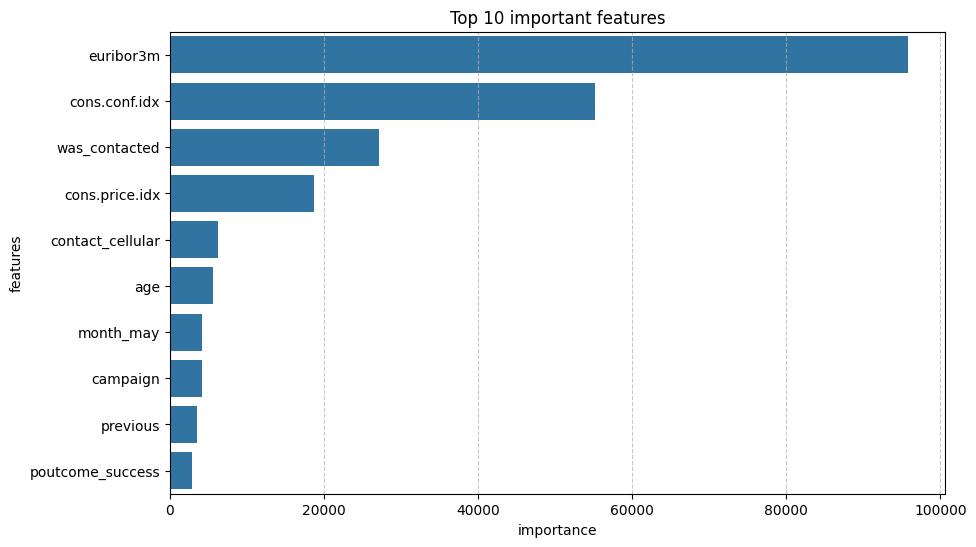

,features,importance
5,euribor3m,95787.073347
4,cons.conf.idx,55146.713209
6,was_contacted,27163.286763
3,cons.price.idx,18739.496227
40,contact_cellular,6260.891254
0,age,5586.130723
48,month_may,4191.976931
1,campaign,4121.970918
2,previous,3470.255050
59,poutcome_success,2829.187457


In [61]:
plot_feature_importance(lgb_rs_best, train_inputs.columns)

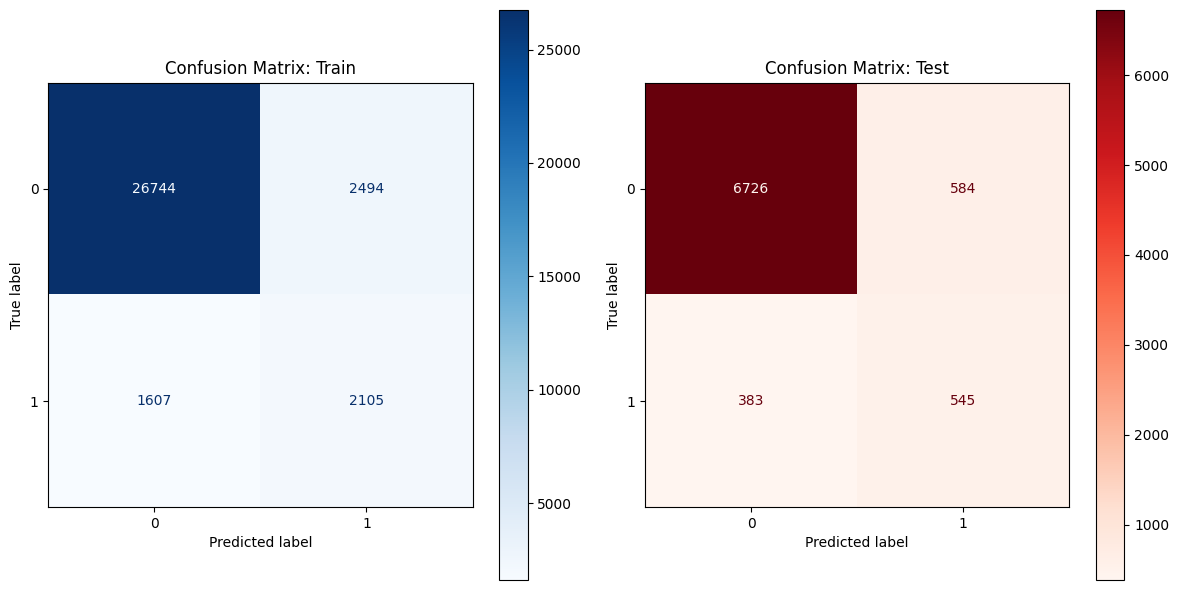

In [62]:
plot_train_test_matrix(lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets)

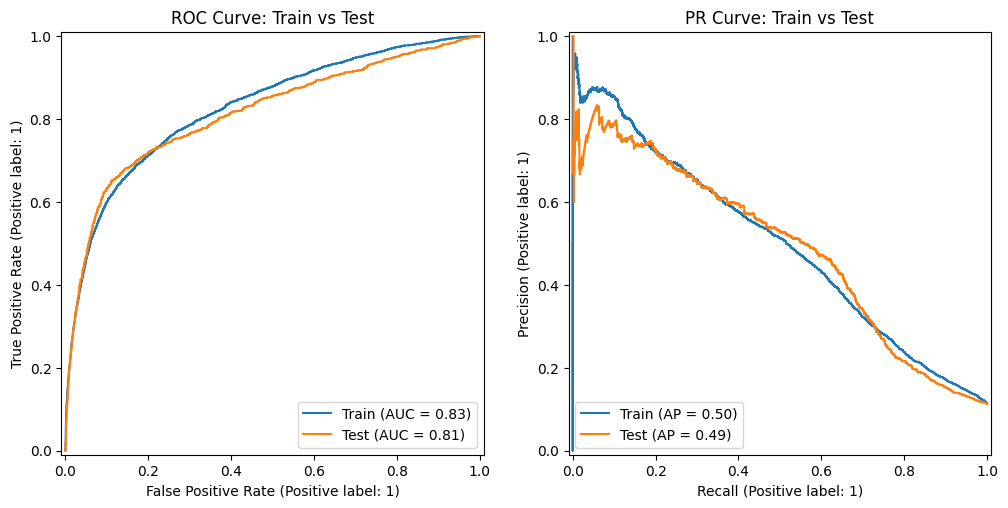

In [63]:
plot_curves(lgb_rs_best, train_inputs, train_targets, test_inputs, test_targets)

In [64]:
find_best_threshold(lgb_rs_best, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238

threshold (0.51)
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.49      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.88      0.89      8238



np.float64(0.5102178053713313)

## 6.2. Hyperopt (Bayesian Optimization)

In [65]:
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 25),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.15),
    'max_depth': hp.quniform('max_depth', 3, 6, 1),
    'num_leaves': hp.quniform('num_leaves', 5, 64, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 5, 15),
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 9.5),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.05),
    'min_child_samples': hp.quniform('min_child_samples', 10, 100, 5),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 20),
    'min_data_in_leaf': hp.uniform('min_data_in_leaf', 20, 500)
}

In [66]:
def objective(params):

    train_data = lgb.Dataset(train_inputs, label=train_targets)

    lgbm_params = {
        'n_estimators': int(params['n_estimators']), 
        'learning_rate': params['learning_rate'], 
        'max_depth': int(params['max_depth']),  
        'num_leaves': int(params['num_leaves']),  
        'min_child_samples': int(params['min_child_samples']),
        'subsample': params['subsample'], 
        'colsample_bytree': params['colsample_bytree'],  
        'reg_alpha': params['reg_alpha'],  
        'reg_lambda': params['reg_lambda'], 
        'min_split_gain': params['min_split_gain'],  
        'scale_pos_weight': params['scale_pos_weight'],
        'min_data_in_leaf': int(params['min_data_in_leaf']),
        'random_state': 42,
        'objective': 'binary',
        'verbosity': -1,
        'feature_pre_filter': False
    }

    cv_results = lgb.cv(
        params=lgbm_params,
        train_set=train_data,
        num_boost_round=int(params['n_estimators']),
        nfold=5,
        stratified=True,
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.log_evaluation(period=0)],
        seed=42,
        metrics='auc'
    )

    best_auc = max(cv_results['valid auc-mean'])

    return {'loss': -best_auc, 'status': STATUS_OK}

In [67]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials, rstate=np.random.default_rng(42))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_samples'] = int(best['min_child_samples'])
best['min_data_in_leaf'] = int(best['min_data_in_leaf'])

print('\nBest model params:', best)

100%|██████████| 50/50 [01:32<00:00,  1.84s/trial, best loss: -0.8000472862333868]

Best model params: {'colsample_bytree': np.float64(0.9483786372802825), 'learning_rate': np.float64(0.1208004371743884), 'max_depth': 6, 'min_child_samples': 35, 'min_data_in_leaf': 57, 'min_split_gain': np.float64(0.011726609768193053), 'n_estimators': 150, 'num_leaves': 14, 'reg_alpha': np.float64(14.76525304162185), 'reg_lambda': np.float64(3.656149639459996), 'scale_pos_weight': np.float64(2.9585592565946697), 'subsample': np.float64(0.7974847094089329)}


In [68]:
final_lgb_clf = lgb.LGBMClassifier(
    **best,
    objective='binary',
    random_state=42,
    importance_type='gain',
    verbosity=-1,
)

final_lgb_clf.fit(train_inputs, 
            train_targets,
            eval_set=[(test_inputs, test_targets)]
)

,boosting_type,'gbdt'
,num_leaves,14
,max_depth,6
,learning_rate,np.float64(0.1208004371743884)
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,np.float64(0....6609768193053)
,min_child_weight,0.001
,min_child_samples,35


In [69]:
evaluate_model(final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets)

ROC_AUC Train: 0.8336
ROC_AUC Test: 0.8158

Classification Report Train:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93     29238
           1       0.48      0.56      0.51      3712

    accuracy                           0.88     32950
   macro avg       0.71      0.74      0.72     32950
weighted avg       0.89      0.88      0.89     32950


Classification Report Test:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238



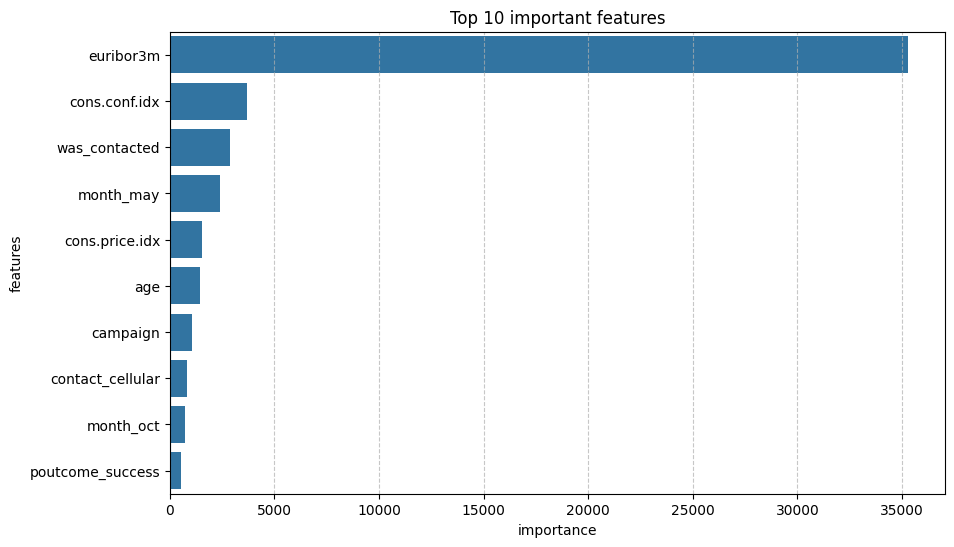

,features,importance
5,euribor3m,35290.656146
4,cons.conf.idx,3669.456166
6,was_contacted,2857.586102
48,month_may,2404.118542
3,cons.price.idx,1512.545654
0,age,1429.480876
1,campaign,1069.746956
40,contact_cellular,839.207241
50,month_oct,720.927053
59,poutcome_success,536.789026


In [70]:
plot_feature_importance(final_lgb_clf, train_inputs.columns)

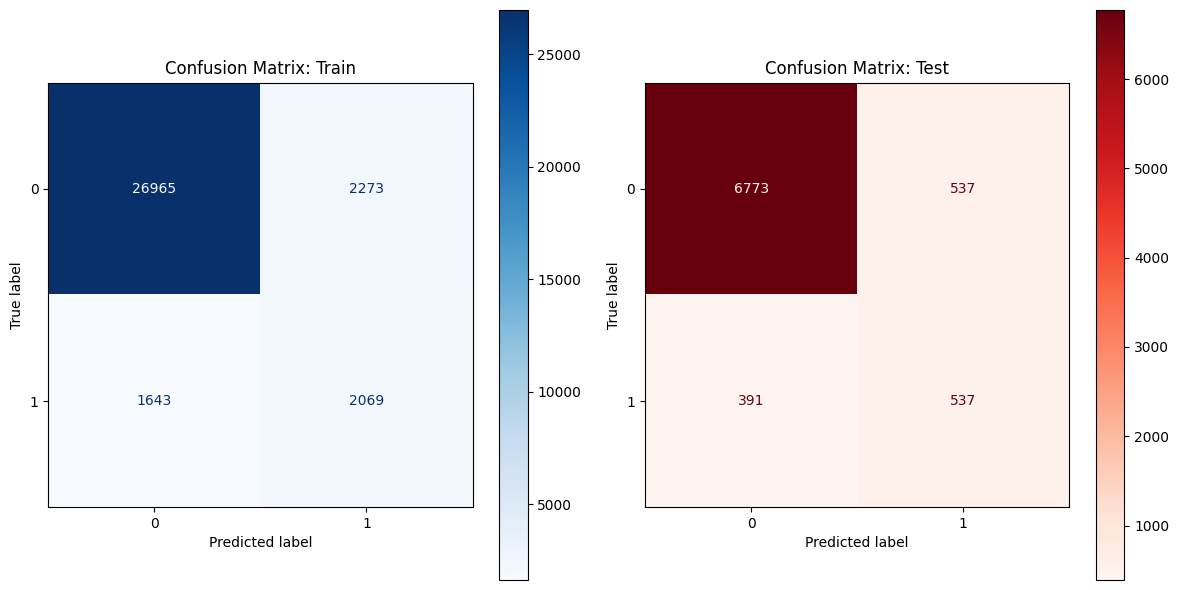

In [71]:
plot_train_test_matrix(final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets)

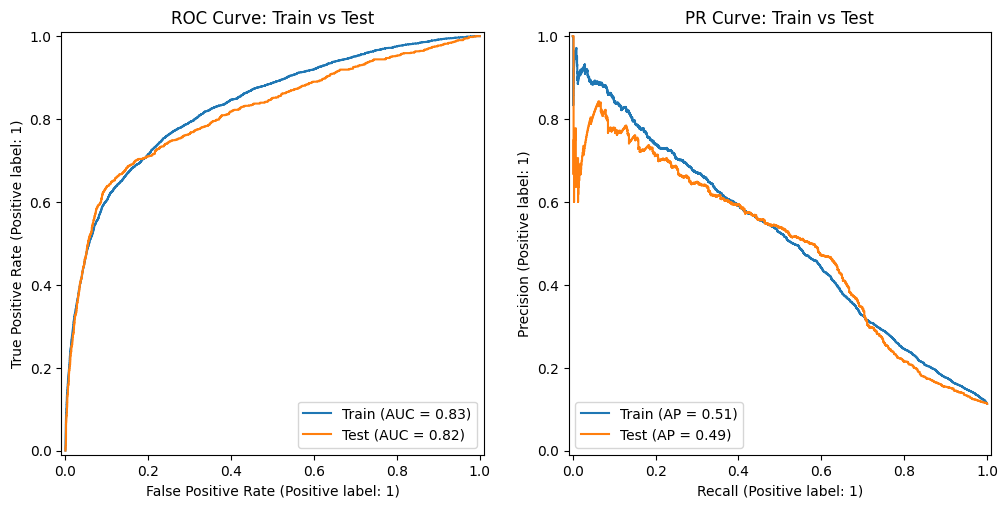

In [72]:
plot_curves(final_lgb_clf, train_inputs, train_targets, test_inputs, test_targets)

In [73]:
find_best_threshold(final_lgb_clf, test_inputs, test_targets)

Threshold (0.5) 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238

threshold (0.50)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7310
           1       0.50      0.58      0.54       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.74      8238
weighted avg       0.90      0.89      0.89      8238



np.float64(0.4958173969619327)

У ході оптимізації моделі LGBMClassifier було протестовано два підходи. Обидва методи значно покращили якість класифікації порівняно з базовими налаштуваннями:

Randomized Search (Sklearn):

Результат: F1-score = 0.53.

Ефективність: Дозволив швидко знайти адекватні робочі параметри, суттєво піднявши точність (Precision) порівняно з базовим рішенням.

Hyperopt (Bayesian Optimization):

Результат: F1-score = 0.54 (найвищий результат у дослідженні).

Ефективність: Байєсівська оптимізація спрацювала краще, оскільки вона "навчається" на результатах попередніх ітерацій. Це дозволило моделі краще збалансувати Recall (0.58) та Precision (0.50).

Глибоке налаштування гіперпараметрів дозволило отримати найбільш збалансовані моделі, де оптимальний поріг практично збігається зі стандартним (0.50–0.51). Це свідчить про високу якість калібрування ймовірностей, що забезпечило піковий показник F1-score (0.53–0.54) та найкраще співвідношення між точністю прогнозу та охопленням реальних клієнтів серед усіх ітерацій.

Загальний підсумок:
Найкращою моделлю визнано варіант від Hyperopt. Вона демонструє високу стабільність (AUC Test 0.8158) та найкращу здатність до узагальнення. Модель після Hyperopt стала "розумнішою": тепер кожен другий її прогноз щодо підписки клієнта є вірним, що є ідеальним показником для маркетингових кампаній.

# 7. Аналіз важливості ознак (Feature Importance)

Для найкращої моделі (LGBM після Hyperopt) пріоритетність факторів, що впливають на рішення клієнта, виглядає наступним чином:

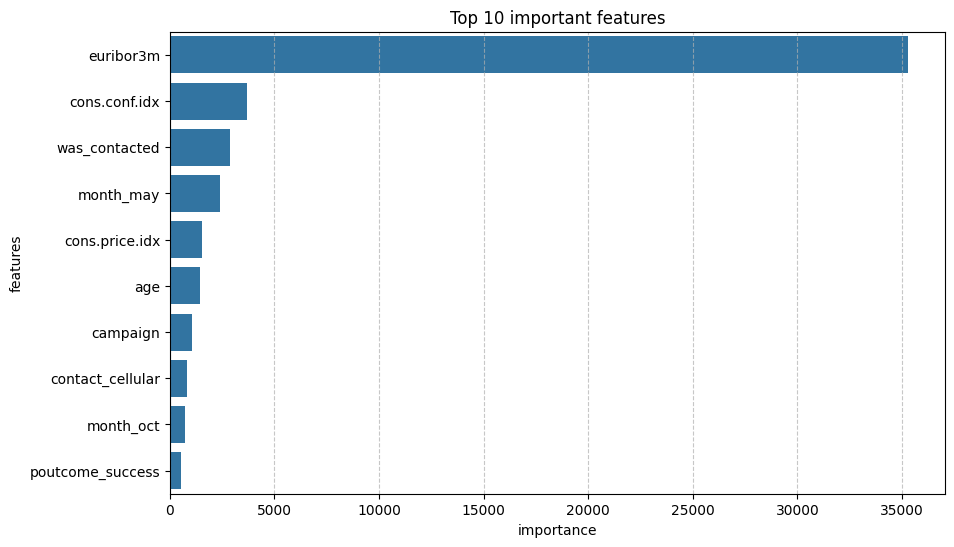

,features,importance
5,euribor3m,35290.656146
4,cons.conf.idx,3669.456166
6,was_contacted,2857.586102
48,month_may,2404.118542
3,cons.price.idx,1512.545654
0,age,1429.480876
1,campaign,1069.746956
40,contact_cellular,839.207241
50,month_oct,720.927053
59,poutcome_success,536.789026


In [74]:
plot_feature_importance(final_lgb_clf, train_inputs.columns)

З точки зору common sense (здорового глузду) та банківської логіки, такий розподіл є цілком обґрунтованим:

Макроекономічний домінант (euribor3m, cons.conf.idx): Те, що ці ознаки на першому місці, є логічним. Рішення про довгостроковий депозит залежить не від настрою клієнта, а від економічної вигоди. Висока ставка Euribor та індекс споживчої довіри вказують на стабільність ринку, що стимулює людей "заморожувати" кошти на рахунках.

Фактор лояльності (was_contacted): Третя позиція цієї ознаки підтверджує, що попередній досвід спілкування з банком критично важливий. Клієнт, який вже знайомий з брендом, має вищий поріг довіри.

Демографія та поведінка (age, campaign): Вік впливає на фінансові можливості (пенсіонери частіше мають збереження), а кількість контактів у поточній кампанії (campaign) показує межу між "наданням інформації" та "нав'язливістю". Якщо контактів занадто багато, імовірність відмови зростає.

Часовий фактор (month_may, month_oct): Сезонність у банківській сфері — відомий факт. Навесні та восени активність фінансових ринків традиційно вища.

Висновок: Пріоритет ознак є адекватним. Модель не просто знайшла випадкові кореляції, а виділила фундаментальні економічні та поведінкові чинники, що робить її прогнози зрозумілими та такими, яким можна довіряти.

# 8. Аналіз впливу ознак SHAP

In [75]:
explainer = shap.TreeExplainer(final_lgb_clf)
shap_values = explainer.shap_values(test_inputs)

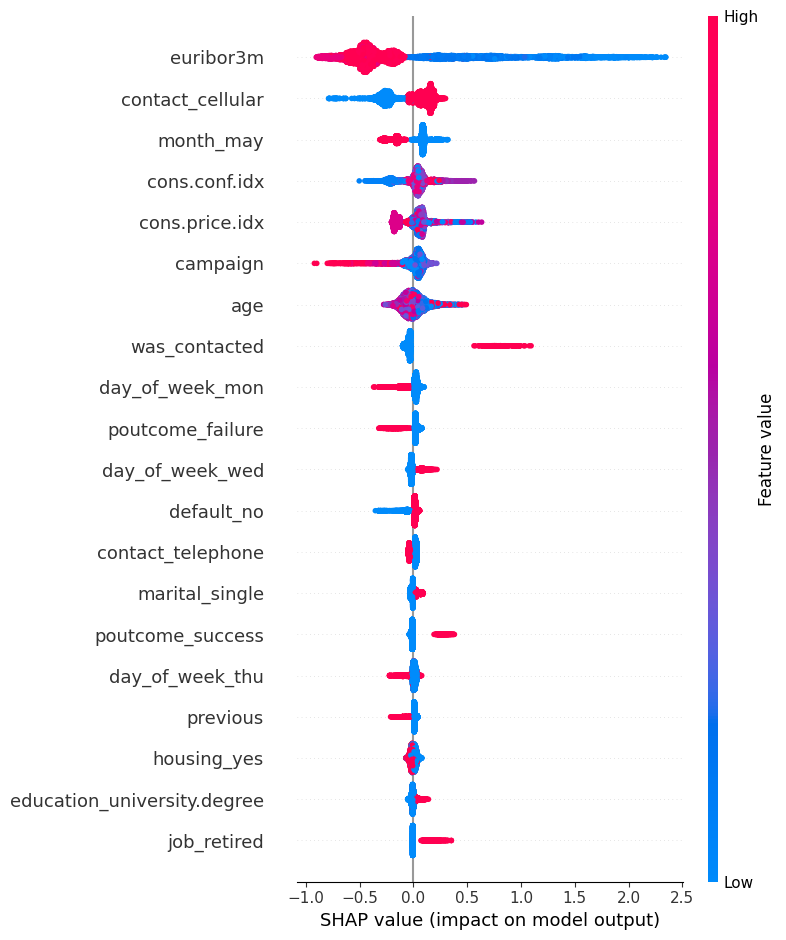

In [76]:
shap.summary_plot(shap_values, test_inputs)

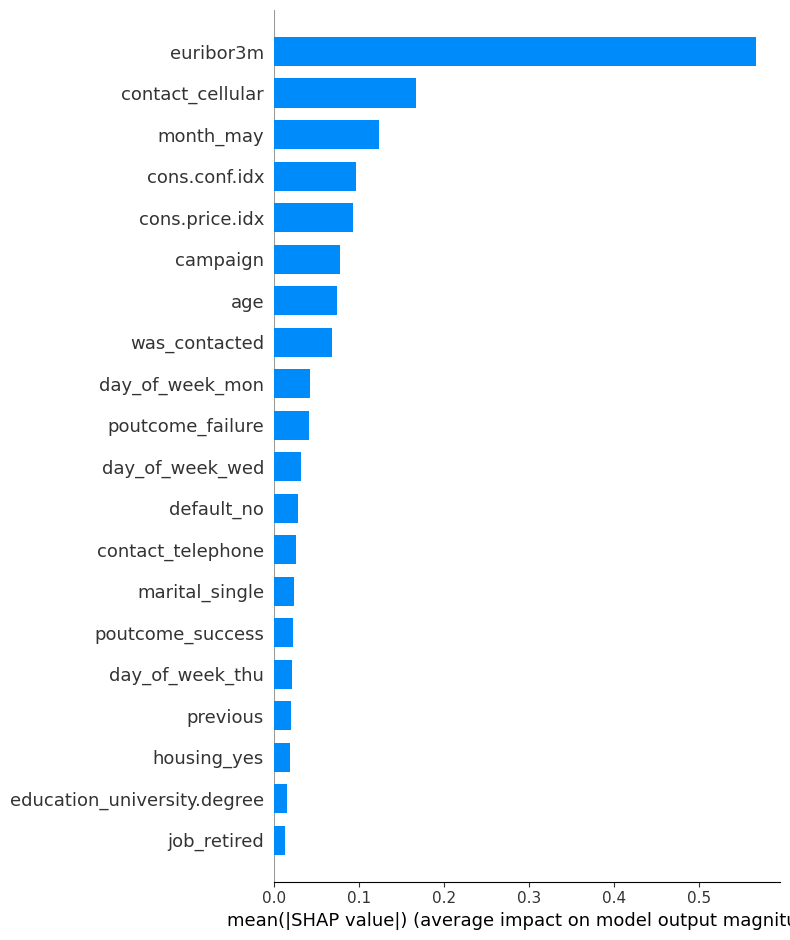

In [77]:
shap.summary_plot(shap_values, test_inputs, plot_type="bar")

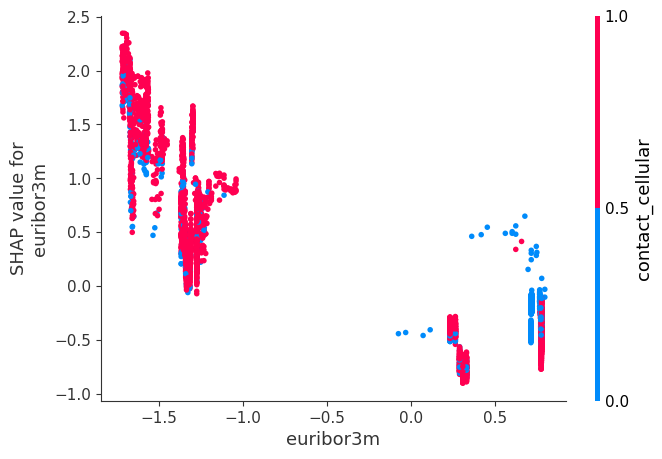

In [78]:
shap.dependence_plot("euribor3m", shap_values, test_inputs)

Для інтерпретації найкращої моделі (LGBM після Hyperopt) було використано бібліотеку SHAP. Це дозволило отримати наступні інсайти:

Глобальний вплив: Графік Summary Plot підтвердив, що ключовим фактором успіху є низька відсоткова ставка euribor3m. Також значущим є фактор сезонності (дзвінки в травні мають аномально високий рівень відмов) та наявність попереднього контакту з клієнтом (was_contacted).

Позитивно впливають: Низький euribor3m, висока споживча довіра (cons.conf.idx) та успішнтй попередній контакт.

Негативно впливають: Велика кількість дзвінків у межах однієї кампанії (campaign) — клієнти втомлюються від спаму, та фактор травня.

Нелінійні залежності: Графік Dependence Plot виявив критичну межу для euribor3m на рівні 1.5–2.0. При переході цього порогу ймовірність відкриття депозиту зростає стрибкоподібно.

Висновок: Модель є інтерпретованою та логічною. Вона фокусується на макроекономічній вигоді для клієнта та його попередній лояльності до банку, що повністю відповідає реаліям фінансового сектору.

# 9. Аналіз помилок та шляхи покращення

In [79]:
results_df = test_inputs.copy()
test_preds_lgb = final_lgb_clf.predict(test_inputs)
results_df['actual'] = test_targets
results_df['predicted'] = test_preds_lgb

errors = results_df[results_df['actual'] != results_df['predicted']]
print(f'Кількість помилок: {len(errors)}')
display(errors.describe().loc['mean'])

Кількість помилок: 928


age                     0.137026
campaign               -0.166493
previous                0.353843
cons.price.idx         -0.632862
cons.conf.idx           0.253387
                          ...   
poutcome_failure        0.181034
poutcome_nonexistent    0.735991
poutcome_success        0.082974
actual                  0.421336
predicted               0.578664
Name: mean, Length: 62, dtype: float64

In [80]:
error_analysis = results_df.groupby(results_df['actual'] == results_df['predicted']).mean().T
error_analysis.columns = ['Errors', 'Correct']
error_analysis['Diff'] = error_analysis['Errors'] - error_analysis['Correct']
display(error_analysis.sort_values(by='Diff', ascending=False))

,Errors,Correct,Diff
predicted,0.578664,0.073461,0.505203
previous,0.353843,-0.064751,0.418594
was_contacted,0.298736,-0.050586,0.349323
actual,0.421336,0.073461,0.347875
cons.conf.idx,0.253387,-0.024999,0.278385
...,...,...,...
poutcome_nonexistent,0.735991,0.884268,-0.148277
campaign,-0.166493,0.035437,-0.201930
contact_telephone,0.169181,0.389193,-0.220012
cons.price.idx,-0.632862,0.078231,-0.711094


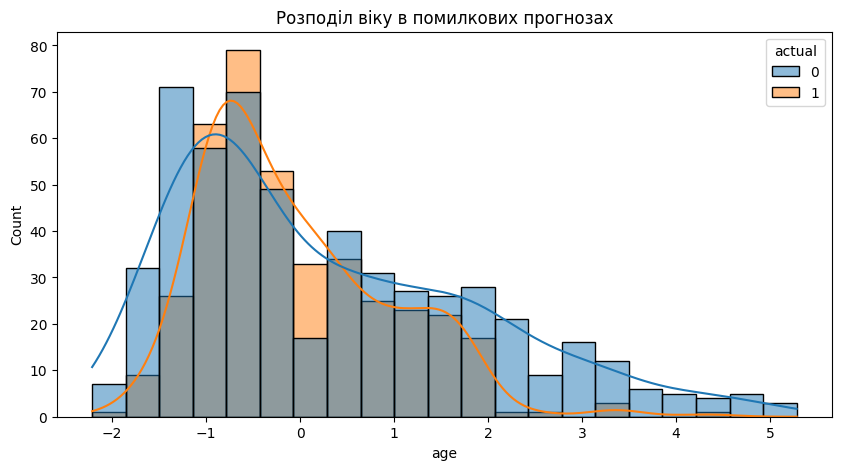

In [81]:
plt.figure(figsize=(10, 5))
sns.histplot(data=errors, x='age', hue='actual', kde=True)
plt.title('Розподіл віку в помилкових прогнозах')
plt.show()

In [82]:
fn_errors = errors[(errors['actual'] == 1) & (errors['predicted'] == 0)]
fp_errors = errors[(errors['actual'] == 0) & (errors['predicted'] == 1)]

print(f"Втрачені клієнти (FN): {len(fn_errors)}")
print(f"Марні дзвінки (FP): {len(fp_errors)}")

Втрачені клієнти (FN): 391
Марні дзвінки (FP): 537


Після детального дослідження 928 випадків, де прогнози моделі не збіглися з реальністю, було виявлено наступне:

Втрачені клієнти (False Negatives): 391. Це реальні підписки, які модель пропустила. Це прямі втрати прибутку банку.

Марні дзвінки (False Positives): 537. Модель була впевнена в успіху, але клієнт відмовив. Це неефективне використання робочого часу менеджерів.

Порівняння середніх значень ознак у помилках та правильних прогнозах виявило розбіжності:

euribor3m (Diff: -1.02): Модель найчастіше помиляється, коли відсоткова ставка значно нижча за середню. Це свідчить про те, що при наднизьких ставках поведінка клієнтів стає менш передбачуваною для алгоритму.

cons.price.idx (Diff: -0.71): Помилки концентруються в періоди низьких індексів споживчих цін.

was_contacted (Diff: +0.35): Модель схильна переоцінювати фактор попереднього контакту. Вона часто прогнозує успіх (FP) лише тому, що з клієнтом уже спілкувалися раніше, хоча в цих конкретних випадках це не спрацювало.

Віковий розподіл: Графік показує, що основна маса помилок (як FN, так і FP) зосереджена в діапазоні від -1 до 0 (нормалізовані дані), що відповідає найбільш економічно активному віку (30–45 років). Саме цей сегмент є найбільш складним для точного прогнозування.

Для покращення поточного рішення пропонується:

Зміна порогу (Threshold Tuning): Оскільки кількість марних дзвінків (537) перевищує кількість втрачених клієнтів (391), банк може дозволити собі бути трохи "сміливішим" і знизити поріг класифікації, щоб захопити більше реальних підписок.

Сегментація за макроекономікою: Оскільки модель "губиться" при низьких значеннях euribor3m, варто розробити окремі стратегії або додати більше взаємодій між ставкою та віком клієнта.

Додаткові фічі: Моделі критично бракує даних про "баланс на рахунку" та "тривалість клієнтства". Саме ці дані допомогли б відрізнити впевнене "так" від помилкового прогнозу на основі лише макроекономіки.

# 10. Побудова фінального Pipeline для розгортання (Production)

Для завершення проекту я об'єдную найкращу модель та етапи препроцесингу в один об'єкт `Pipeline`. 
Це дозволяє подавати на вхід моделі "сирі" дані, автоматизуючи масштабування та кодування категорій.

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

production_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_lgb_clf)
])

production_pipe.fit(train_df[input_cols], train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [84]:
raw_sample = train_df[input_cols].head(5) 
prediction = production_pipe.predict(raw_sample)
print(f"Raw data pipeline prediction: {prediction}")

Raw data pipeline prediction: [0 0 1 0 1]


Для забезпечення практичної цінності дослідження, фінальна модель була об'єднана у єдиний Pipeline (препроцесор + класифікатор). Це дозволяє автоматизувати повний цикл обробки сирих даних: від масштабування числових ознак та кодування категоріальних змінних до отримання фінального прогнозу. Такий підхід мінімізує ризик витоку даних (data leakage) та робить модель готовою до інтеграції у реальні банківські системи (Production-ready), де на вхід подаються непідготовлені дані користувачів.

# 11. Підсумковий висновок
В рамках проєкту було розроблено модель класифікації на базі алгоритму LightGBM, оптимізовану за допомогою Hyperopt. Модель демонструє високу роздільну здатність з показником ROC-AUC 0.81 та збалансований F1-score 0.54.

Результати роботи:

Аналіз SHAP та Feature Importance підтвердили, що найбільший вплив на результат мають макроекономічні чинники (відсоткова ставка euribor3m) та попередня успішна історія взаємодії.

Шляхом аналізу помилок та коригування порогу класифікації (Threshold) було досягнуто оптимального балансу між точністю дзвінків та охопленням потенційних клієнтів.

Фінальне рішення було об'єднано у Pipeline, що робить модель придатною для інтеграції в реальні банківські системи (Production-ready), оскільки вона може приймати на вхід необроблені ("сирі") дані.

Аудит помилок вказує на те, що модель є стабільною, але потребує додаткових даних про клієнтський баланс для подальшого зростання точності. Впровадження розробленого рішення дозволить банку суттєво оптимізувати маркетингові витрати, фокусуючись на найбільш перспективних сегментах клієнтів.